In [1]:
import numpy as np
import matplotlib.pyplot as plt
import py4DSTEM
from os import path
import math
import time
from scipy.optimize import curve_fit
from scipy import optimize
from utils_14 import *

In [2]:
from sklearn.mixture import GaussianMixture

In [3]:
py4DSTEM.__version__

'0.14.14'

In [4]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [8.0, 6.0]

## Data Loading

In [5]:
#import and read data
file_folder = "/Users/weiliu/OneDrive - Northwestern University/Research/Highthroughput/4DSTEM/"
file_name = "Au30Ag10Co20Ni40/SI data (63)/Diffraction SI.dm4"
filepath_input = file_folder+file_name
datacube = py4DSTEM.import_file(filepath_input)

Setting pixel sizes of the datacube failed with error Q pixel units must be 'A^-1', 'mrad' or 'pixels'.


## Particle Identification

In [6]:
#look at data without margin area
datacube_origin = datacube.data[8:-8, 8:-8,:,:]

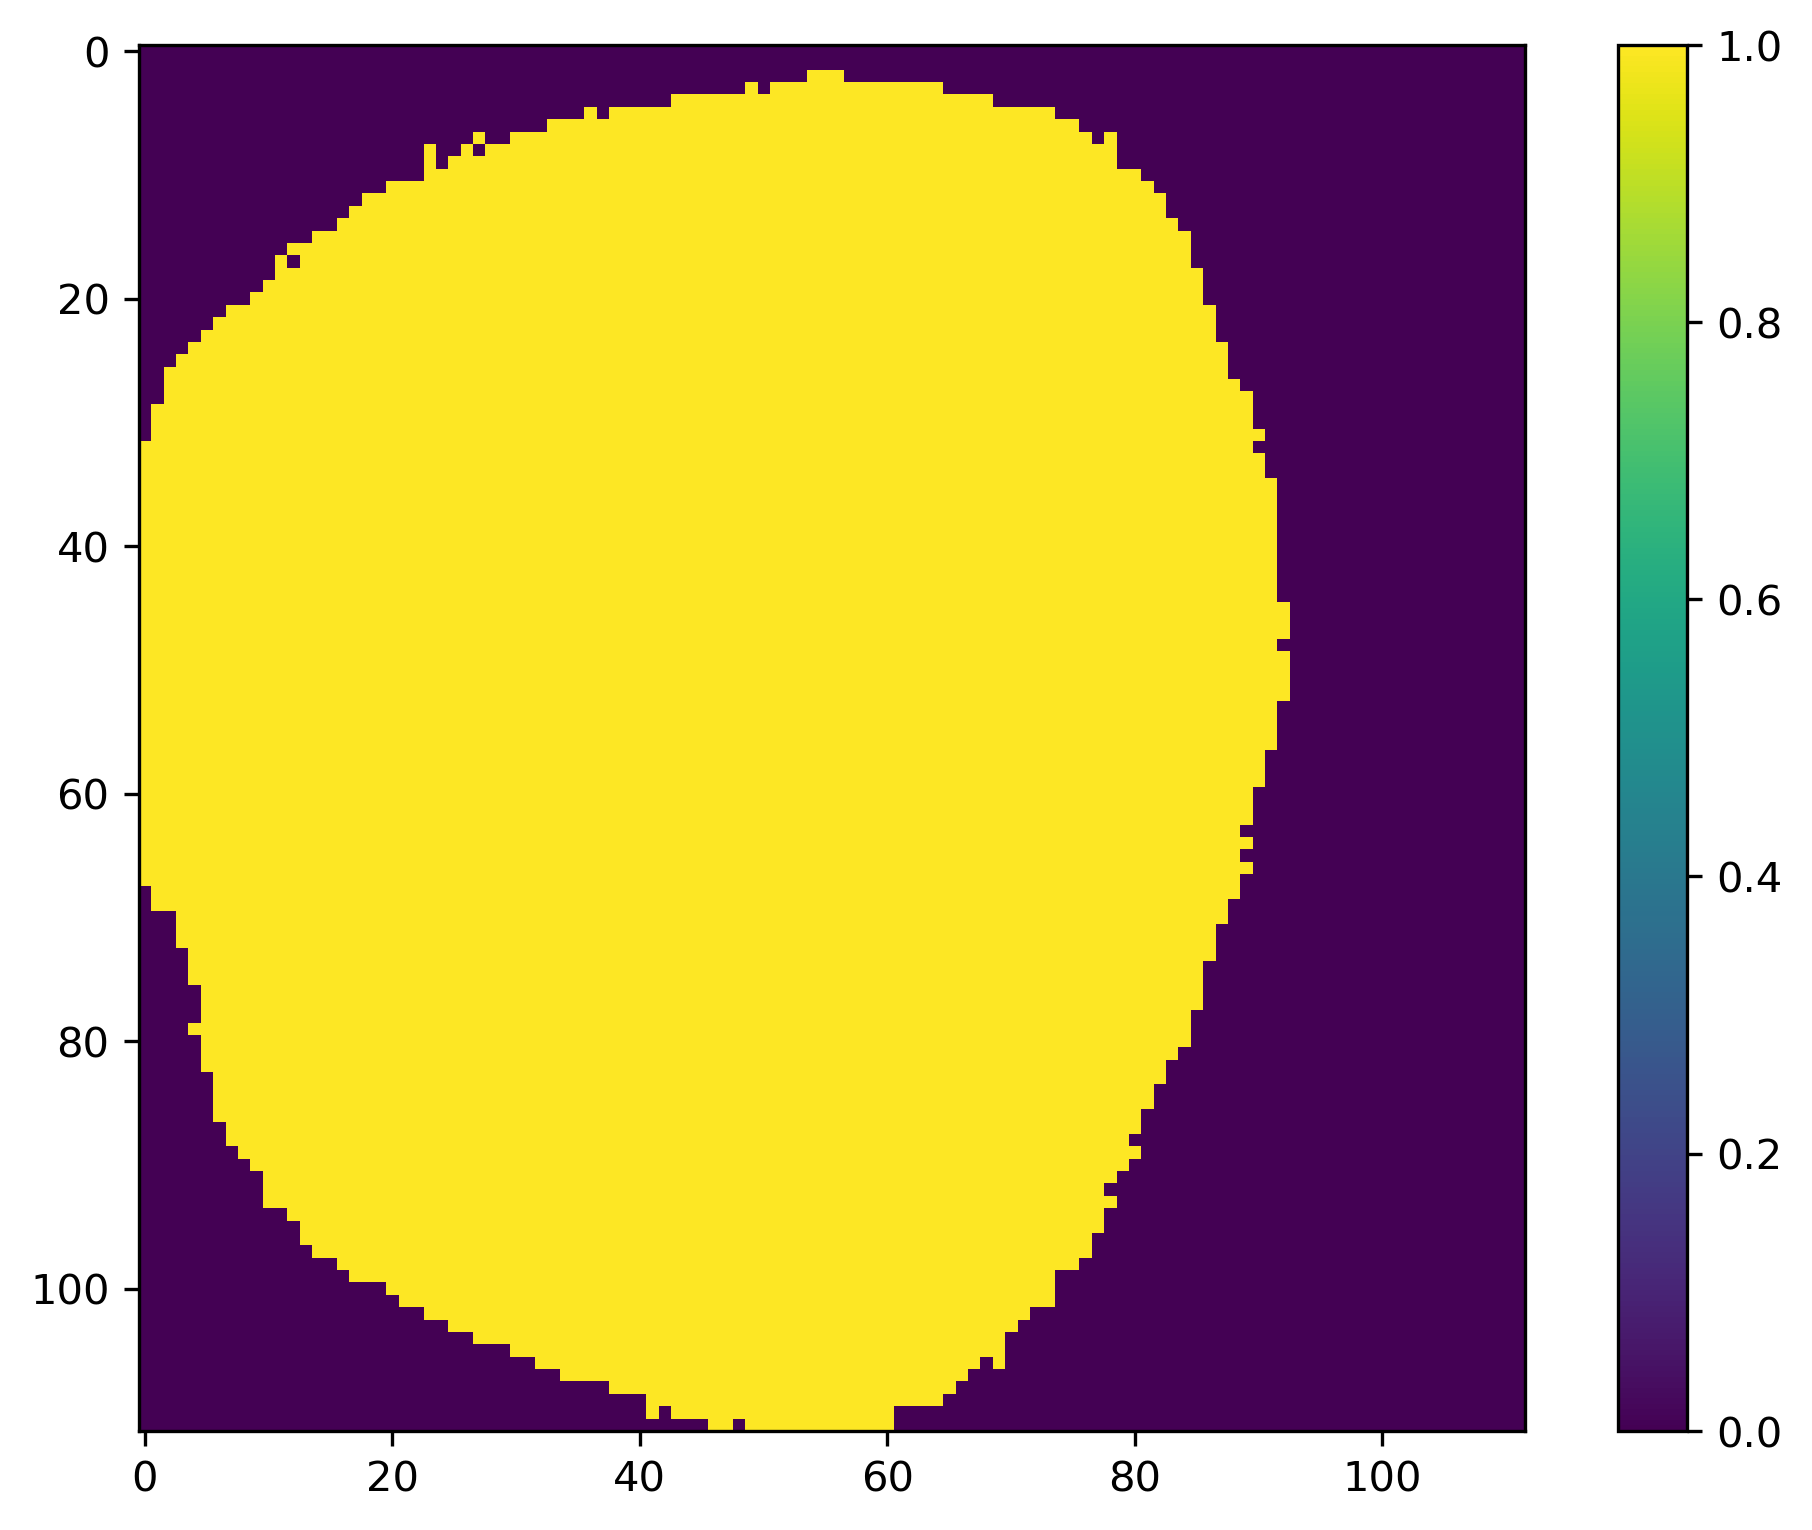

In [7]:
#threshold pixel values to indicate if a pixel belongs to particle area or not
particle_labels = IsParticle(datacube_origin, thres=60000)
plt.imshow(particle_labels);plt.colorbar()

## Average, symmetrization

In [8]:
#datacube_average: after spatially smoothing
#datacube_info: stores average info separately for display
#py4DSTEM function modifies the data in place
#so always keep storage separately if there is display needs in the future
datacube_average, datacube_info = average_datacube(datacube, n=8)

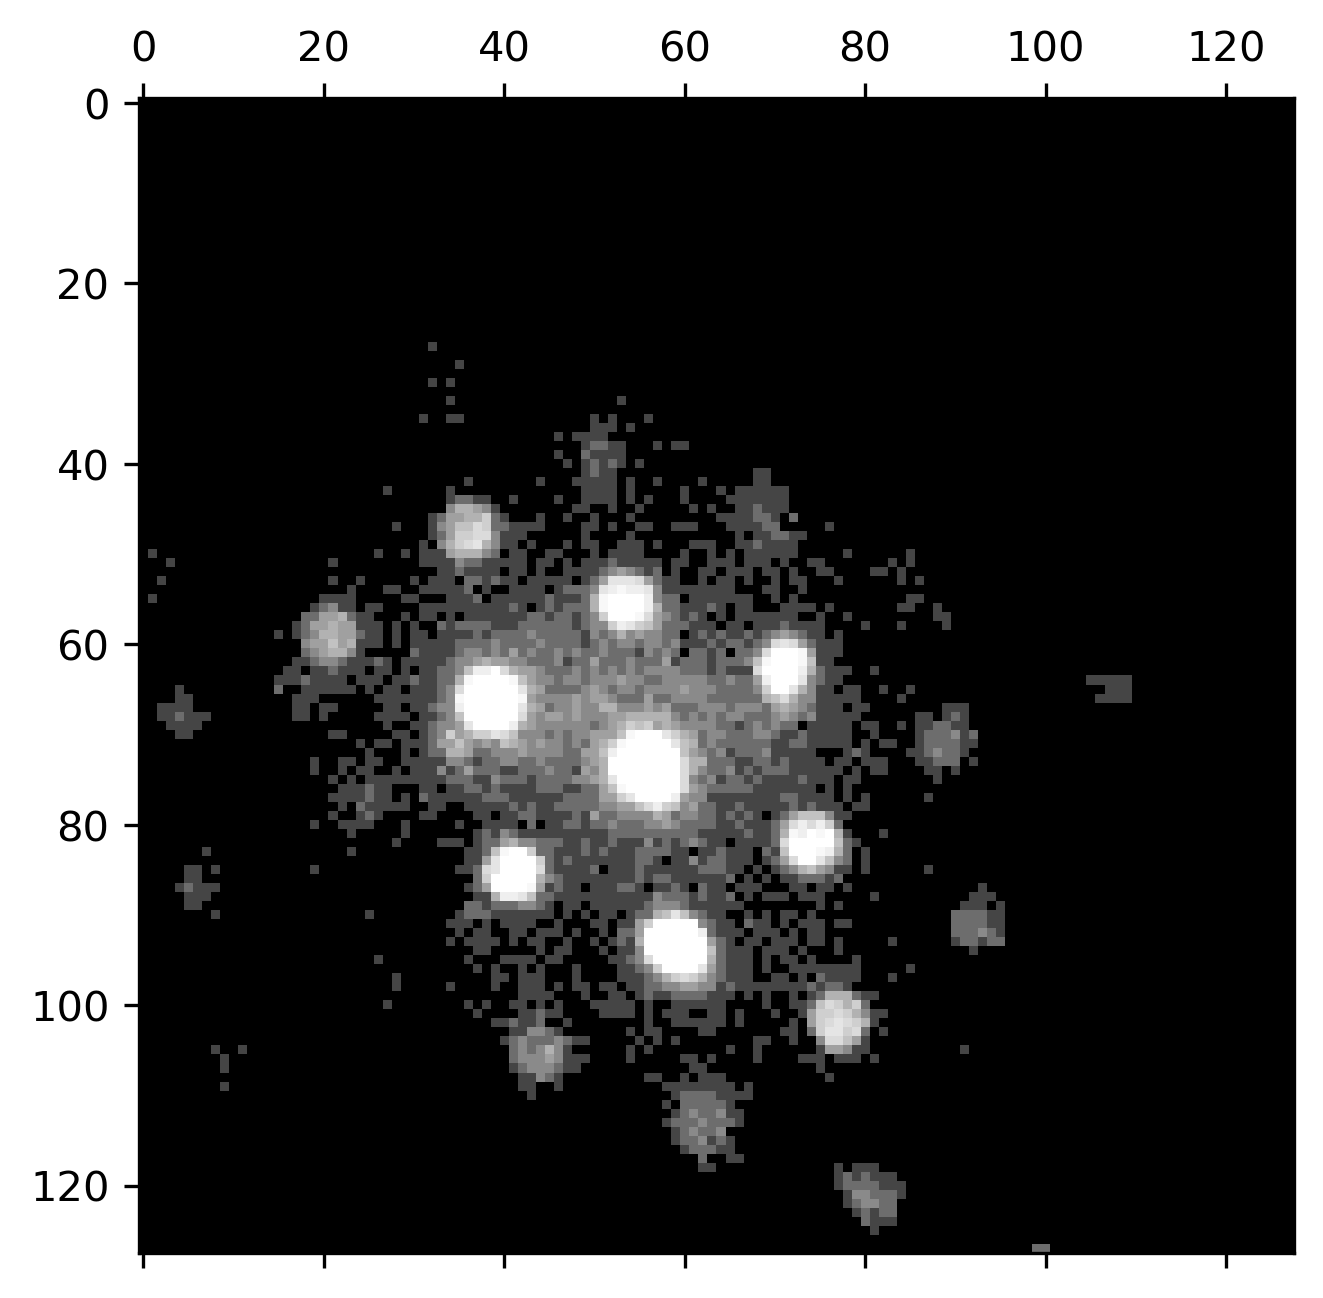

In [9]:
#display the DP at real space with coordinates [100, 40] after log-transformation
py4DSTEM.visualize.show(datacube_info[100][40], scaling='log')

In [10]:
#obtain the probe (kernel)
#use py4dstem functions
#obtain the center coordinates and assign to origin_x, origin_y
p = datacube.get_vacuum_probe()
probe_kernel = p.get_kernel(mode = 'gaussian', sigma=2)
probe_kernel_FT = np.conj(np.fft.fft2(probe_kernel))
n = np.argmax(p.probe.flatten())
origin_x, origin_y = np.unravel_index(n, datacube_average.data.shape[2:])

100%|████████████████████████████████████| 12543/12543 [00:13<00:00, 958.07it/s]


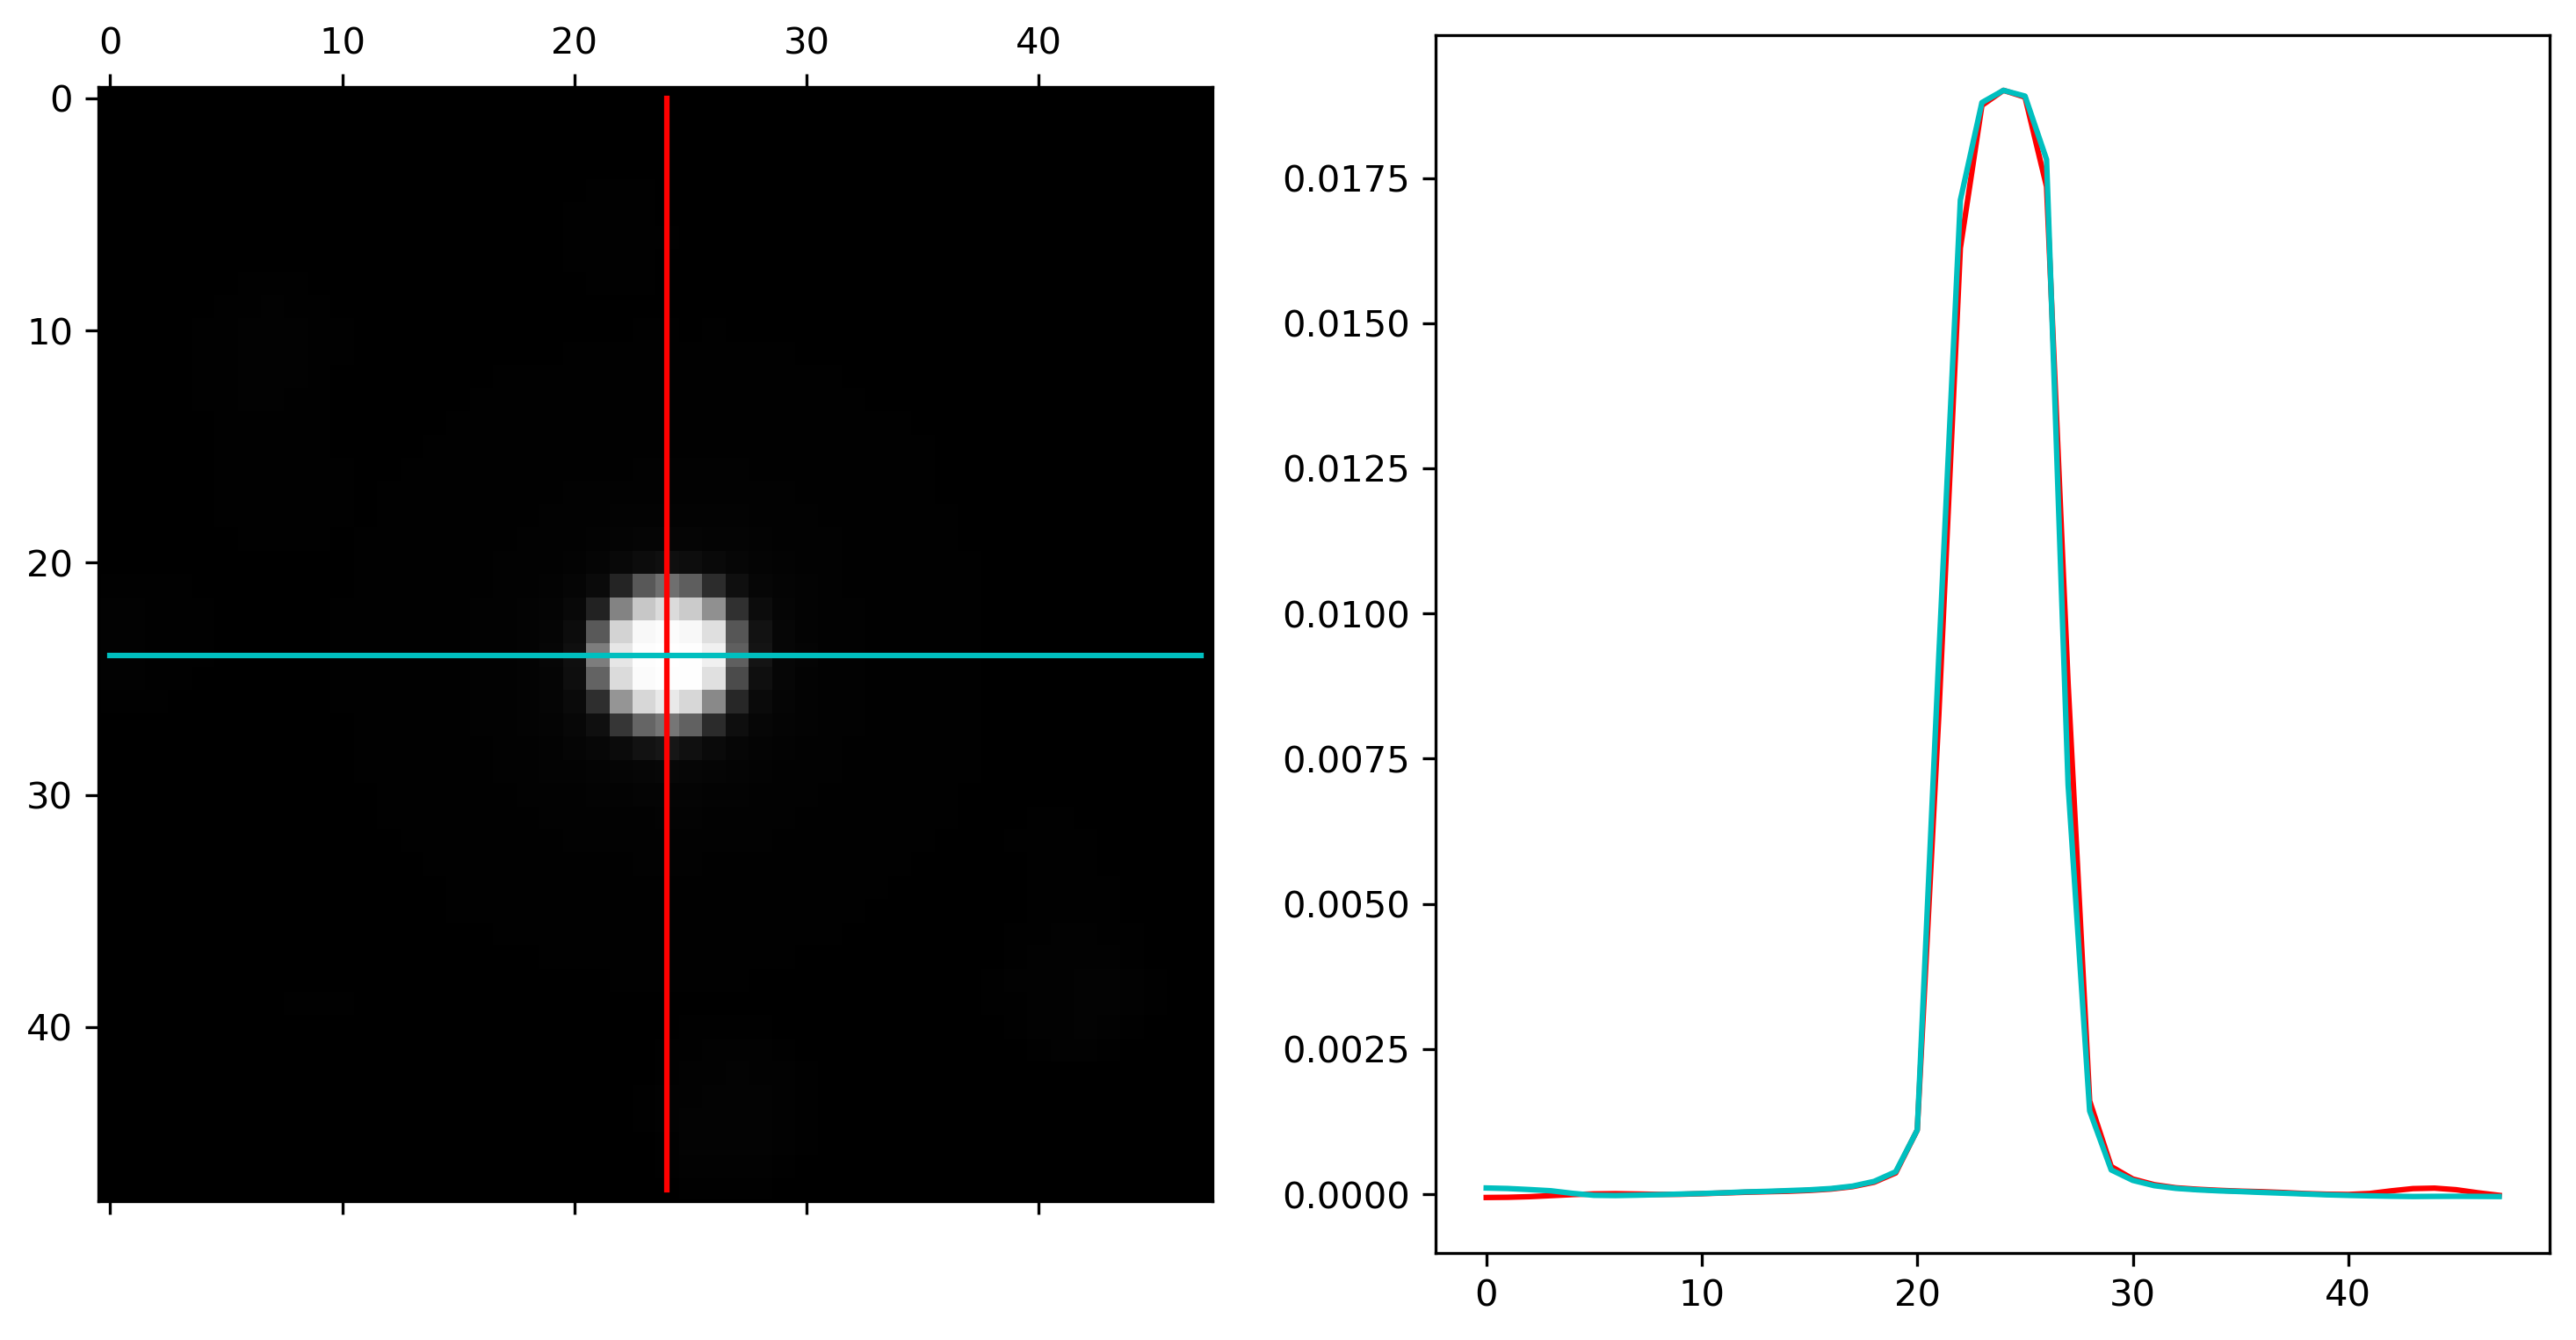

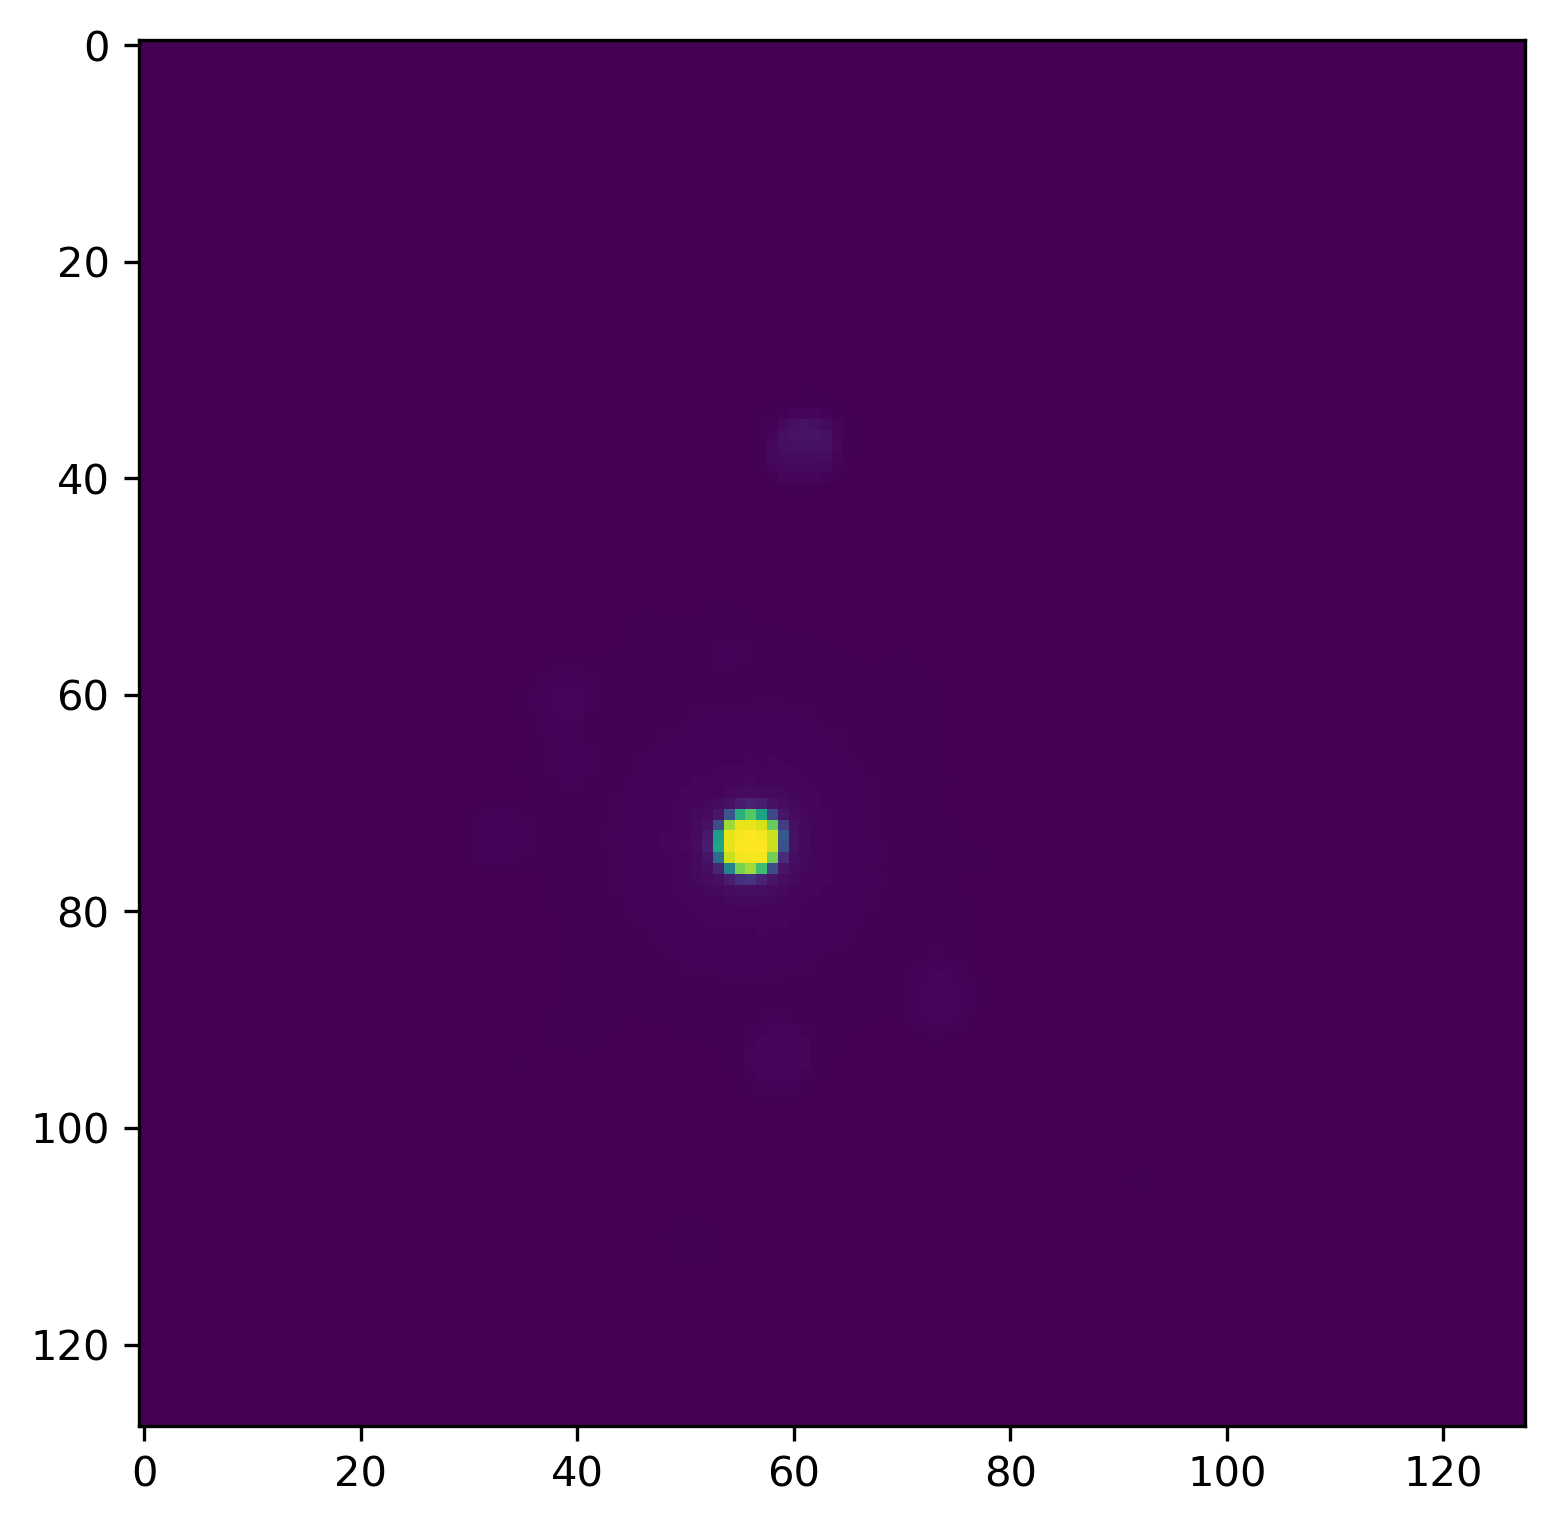

In [11]:
py4DSTEM.visualize.show_kernel(
    p.kernel,
    R = 24,
    L = 24,
    W = 1
)
plt.imshow(p.probe)

In [12]:
#symmetrize the data
datacube_symmetrize, datacube_info_s = symmetrize_datacube(datacube_average, probe_kernel_FT, origin_x=origin_x, origin_y=origin_y)

100%|█████████████████████████████████████| 12544/12544 [02:31<00:00, 82.69it/s]


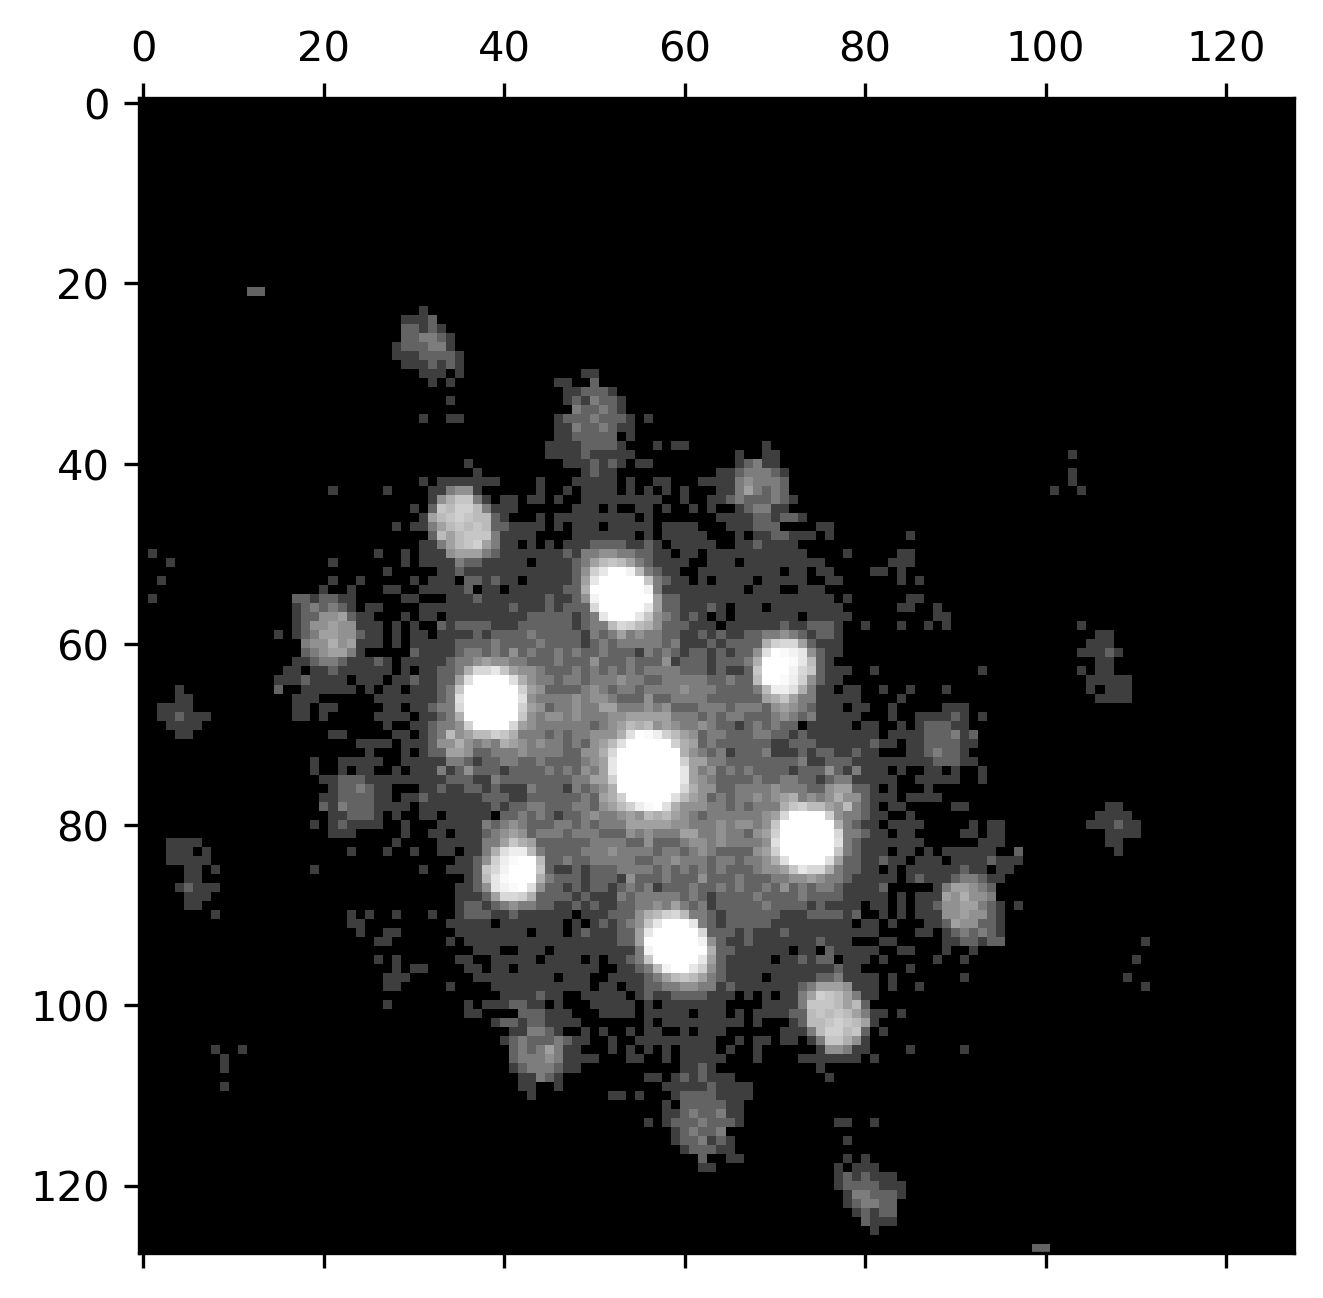

In [13]:
Rx, Ry = 100,40
py4DSTEM.visualize.show(datacube_symmetrize.data[Rx][Ry],scaling='log')

## Background Subtraction

In [14]:
particle_index, nonparticle_index, particle_count = generate_particle_index(datacube_symmetrize, particle_labels)

100%|█████████████████████████████████| 12544/12544 [00:00<00:00, 321821.74it/s]


In [15]:
#obtain the amplitude parameters from pixels in the background region
alpha_bg = bg_param(datacube_symmetrize, nonparticle_index, origin_x, origin_y)

100%|██████████████████████████████████████| 4414/4414 [00:25<00:00, 170.14it/s]


In [16]:
#obtain the estimated parameters of the function fitted to the integrated annular curve
#for all pixels that belong to the particle area
par_param = particle_param(datacube_symmetrize, particle_index, alpha_bg, origin_x, origin_y)

100%|██████████████████████████████████████| 8130/8130 [00:58<00:00, 138.05it/s]


In [17]:
plt.rcParams['font.size'] = 16
plt.rcParams['figure.dpi'] = 300

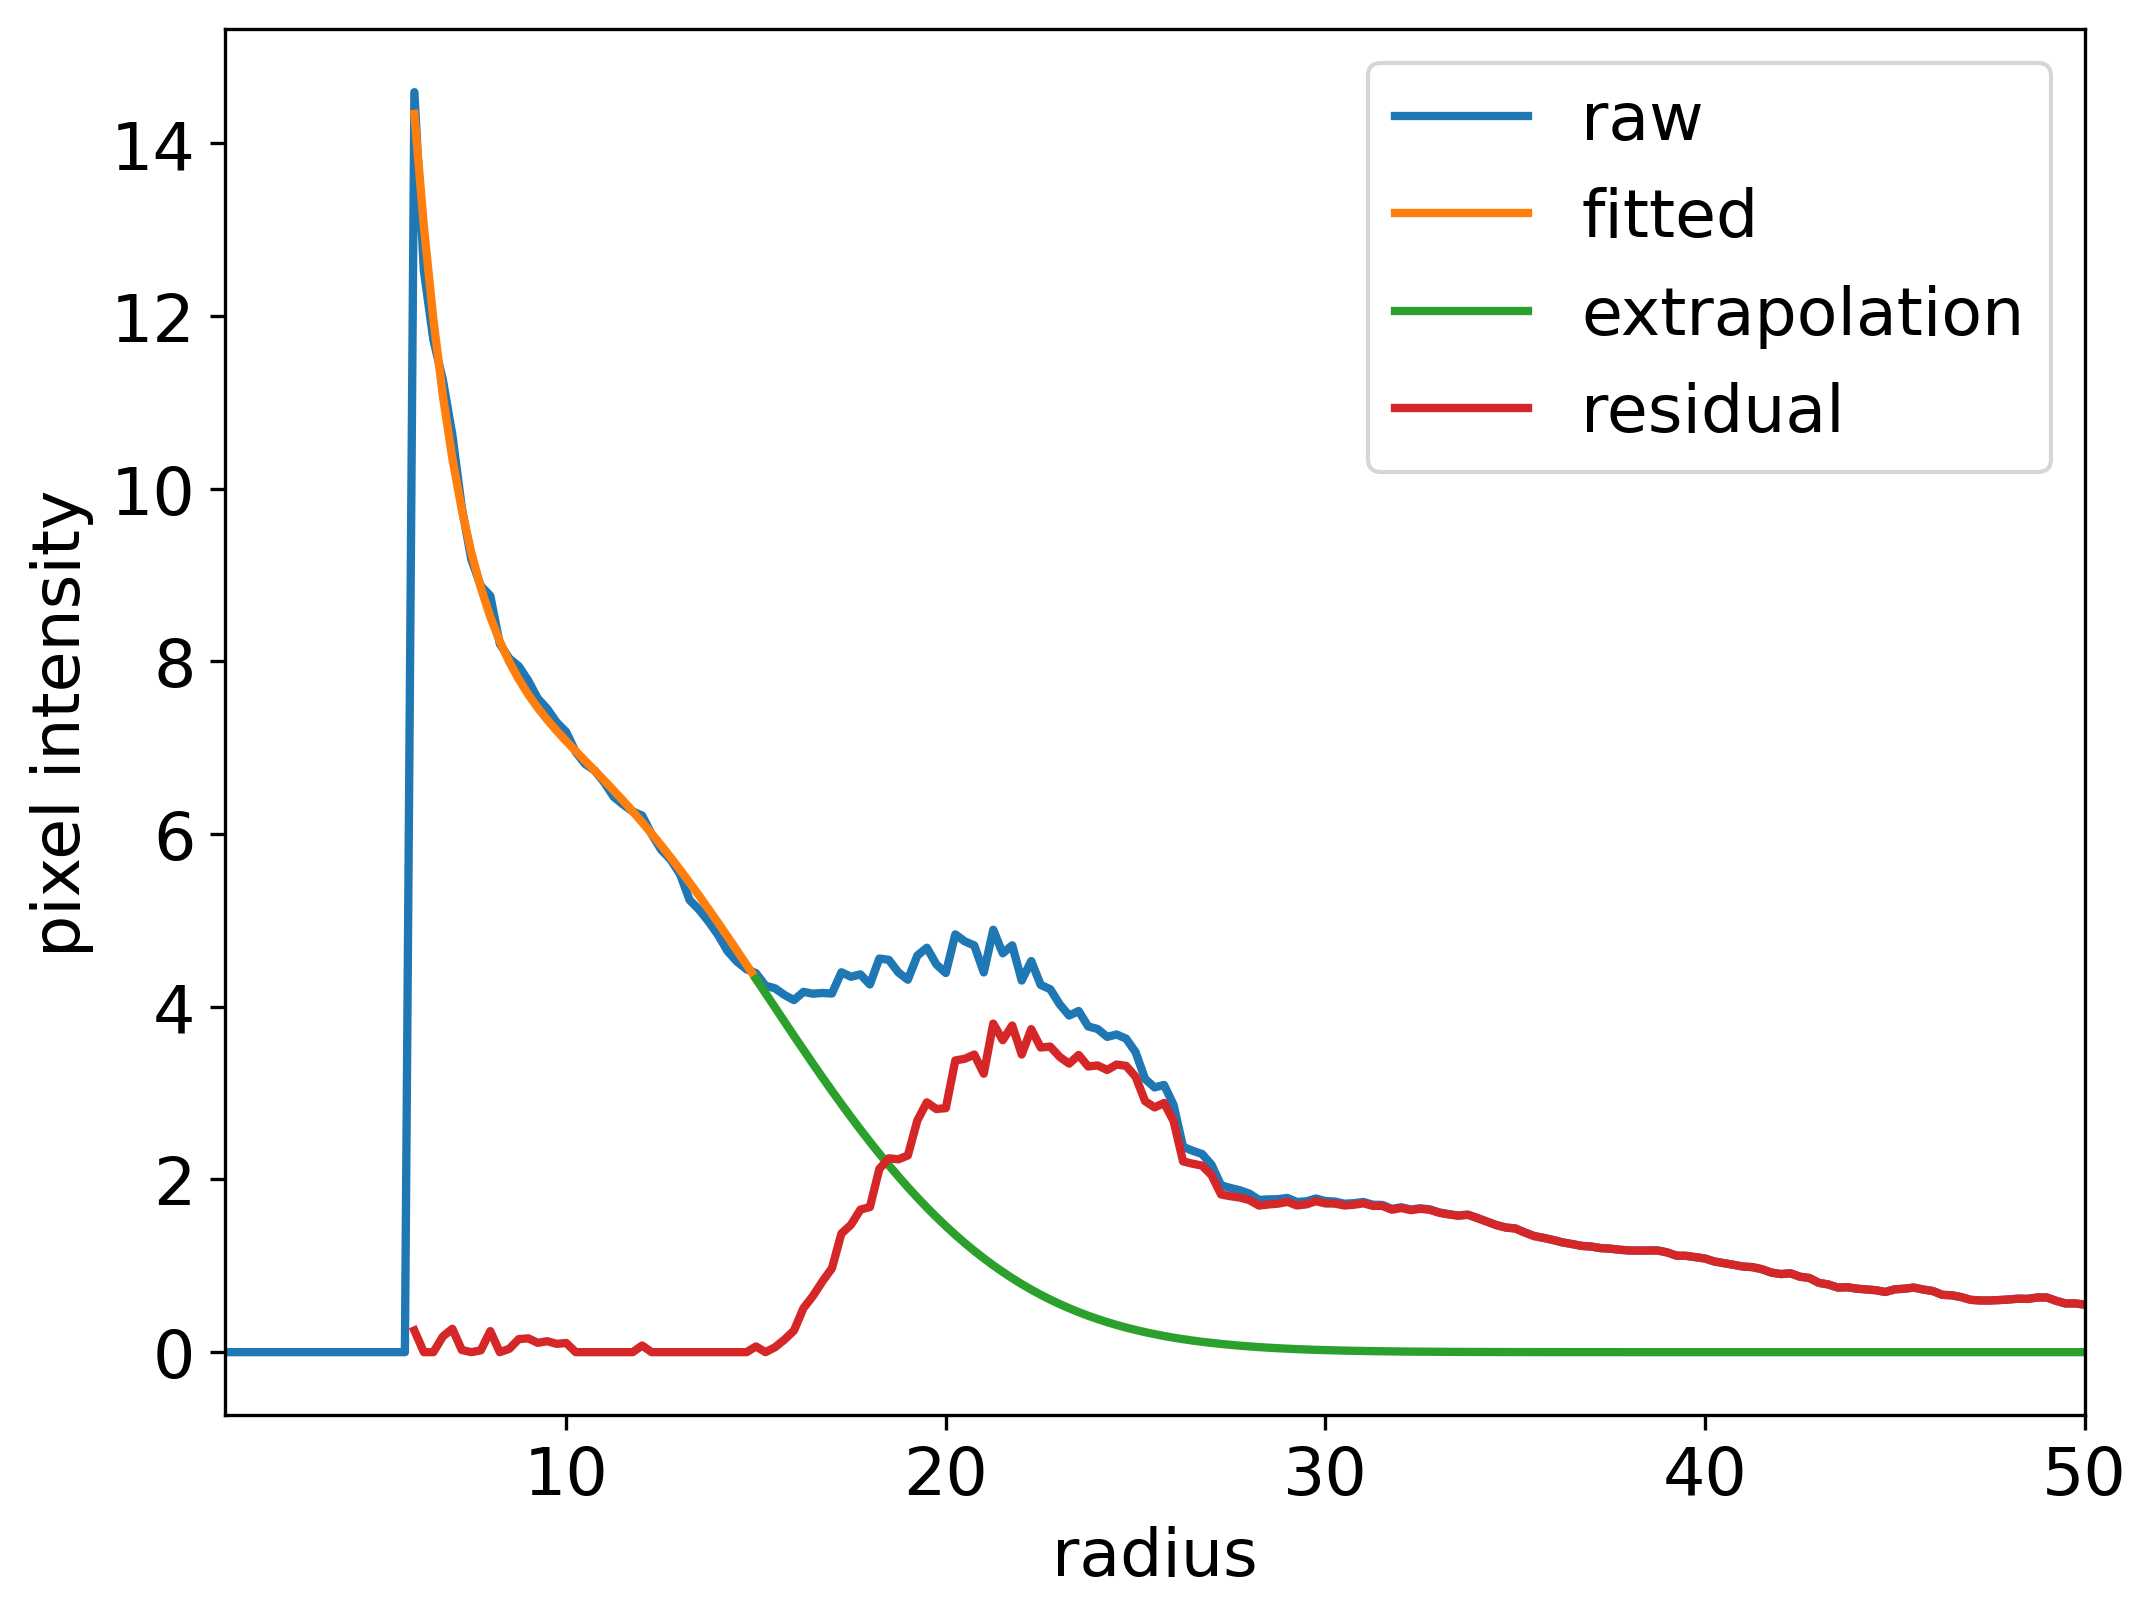

In [18]:
#look at fitted curve for pixle [60,85]
particle_curve(datacube_symmetrize, datacube_info_s, Rx=60, Ry=85, particle_index=particle_index, par_para=par_param, alpha_bg=alpha_bg, origin_x=origin_x, origin_y=origin_y)

In [19]:
#subtract the background from symmetrized DPs
center = [origin_x, origin_y]
datacube_symmetrize = subtract_bg(datacube_symmetrize, particle_index, par_param, center, alpha_bg)

100%|██████████████████████████████████████| 8130/8130 [01:14<00:00, 108.72it/s]


# Bragg disk detection

In [20]:
#pre-specify some parameters for later function usage
corrPower=1
sigma=1
edgeBoundary=2
minRelativeIntensity=0.0001
relativeToPeak=0
minPeakSpacing=1
minAbsoluteIntensity = 0.3
maxNumPeaks=100
subpixel='poly'
upsample_factor=16

In [21]:
# Get disks of all DPs
braggpeaks_raw = py4DSTEM.braggvectors.diskdetection.find_Bragg_disks(
                                data=datacube_symmetrize,
                                template=probe_kernel,
                                corrPower=corrPower,
                                sigma=sigma,
                                edgeBoundary=edgeBoundary,
                                minRelativeIntensity=minRelativeIntensity,
                                relativeToPeak=relativeToPeak,
                                minPeakSpacing=minPeakSpacing,
                                minAbsoluteIntensity=minAbsoluteIntensity,
                                maxNumPeaks=maxNumPeaks,
                                subpixel=subpixel,
                                upsample_factor=upsample_factor
)

Finding Bragg Disks: 100%|████████████████| 12.5k/12.5k [00:10<00:00, 1.16kDP/s]


In [22]:
# delete the local maxima points that are within the center point neighborhood
for n in py4DSTEM.process.utils.tqdmnd(range(datacube_symmetrize.R_N)):
    Rx, Ry = np.unravel_index(n, datacube_symmetrize.data.shape[:2])
    #print(n)
    braggpeaks = braggpeaks_raw.raw[Rx, Ry]._data
    index = [i for i in range(braggpeaks.shape[0]) if math.sqrt((braggpeaks[i][0]-origin_x)**2+(braggpeaks[i][1] - origin_y)**2)<10]
    braggpeaks = np.delete(braggpeaks, index)
    braggpeaks = py4DSTEM.QPoints(braggpeaks)
    braggpeaks_raw._v_uncal[Rx, Ry] = braggpeaks

100%|██████████████████████████████████| 12544/12544 [00:00<00:00, 37810.47it/s]


# Obtain the Bragg vector map (BVM)

In [23]:
bvm_raw = get_bragg_vector_map_raw(braggpeaks_raw,datacube.Q_Nx,datacube.Q_Ny,datacube.R_Nx,datacube.R_Ny)

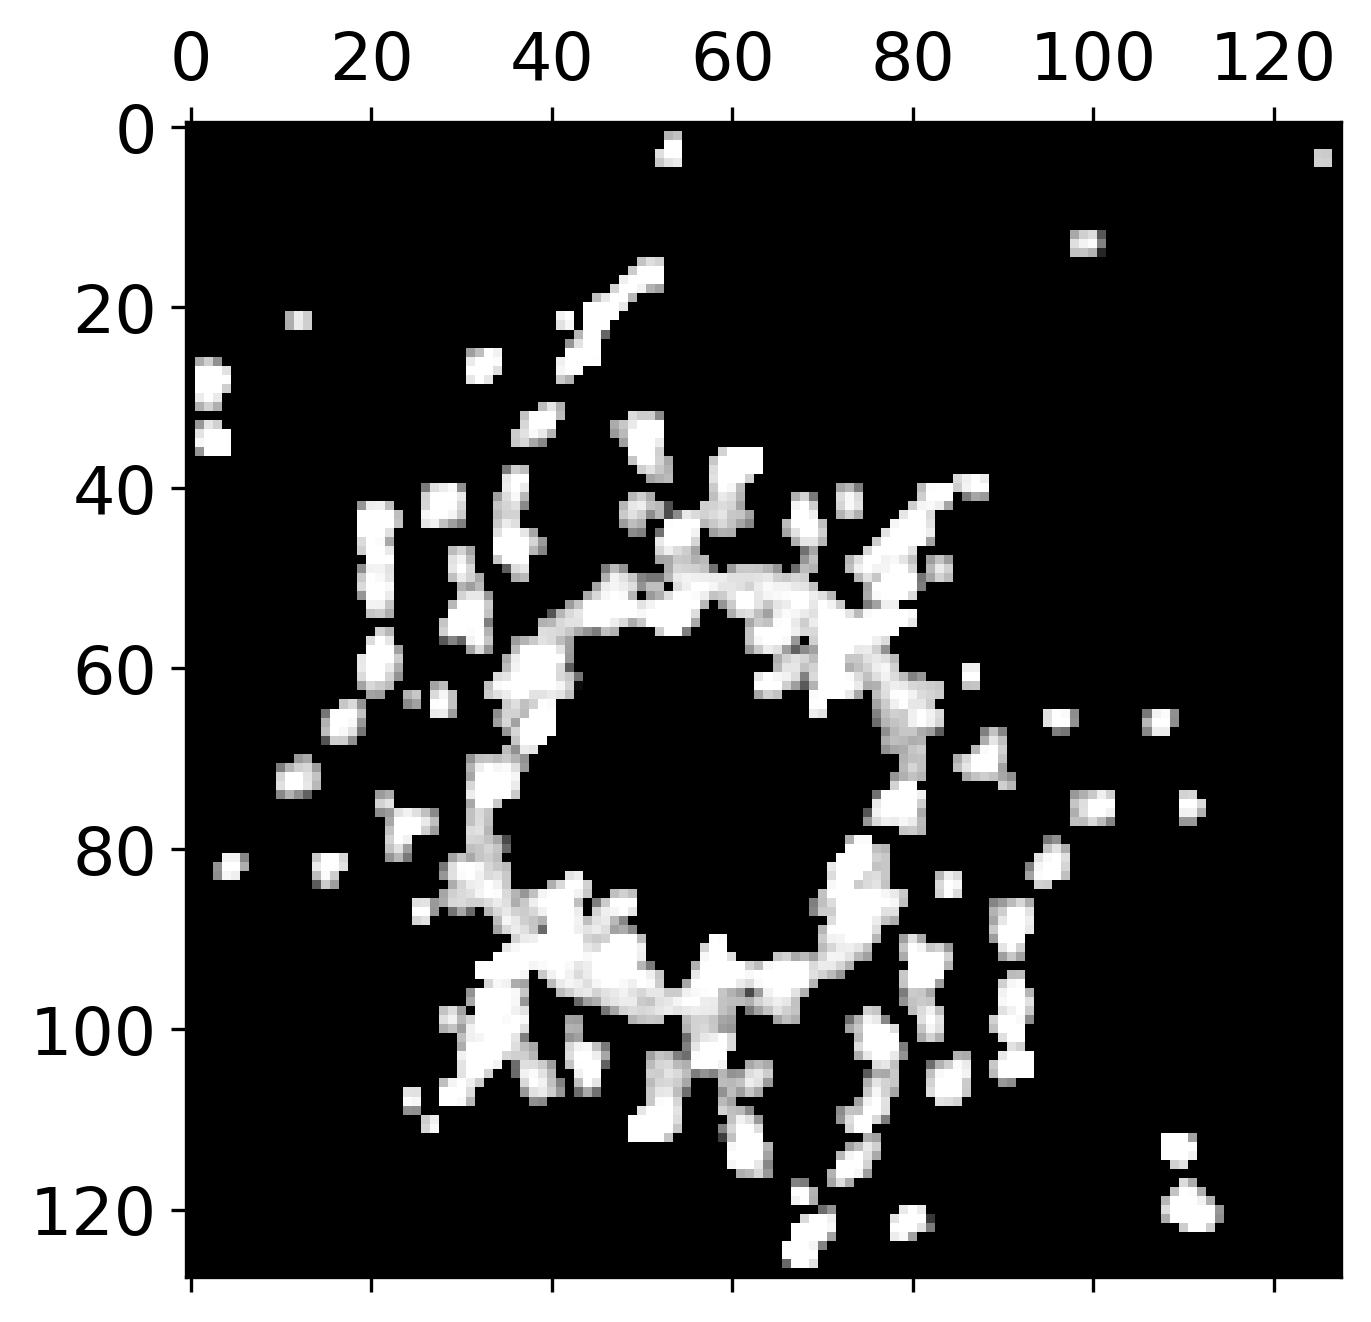

In [24]:
py4DSTEM.visualize.show(bvm_raw,cmap='gray',scaling='log',intensity_range='absolute',vmin=0,vmax=12)

In [25]:
#Obtain local maximum points from bragg vector map
maxima = py4DSTEM.process.utils.get_maxima_2D(
                bvm_raw,
                edgeBoundary=1,
                minSpacing=0,
                minRelativeIntensity=0.001,
                relativeToPeak=0,
                maxNumPeaks=100
)
gx, gy, gI = maxima['x'], maxima['y'], maxima['intensity']

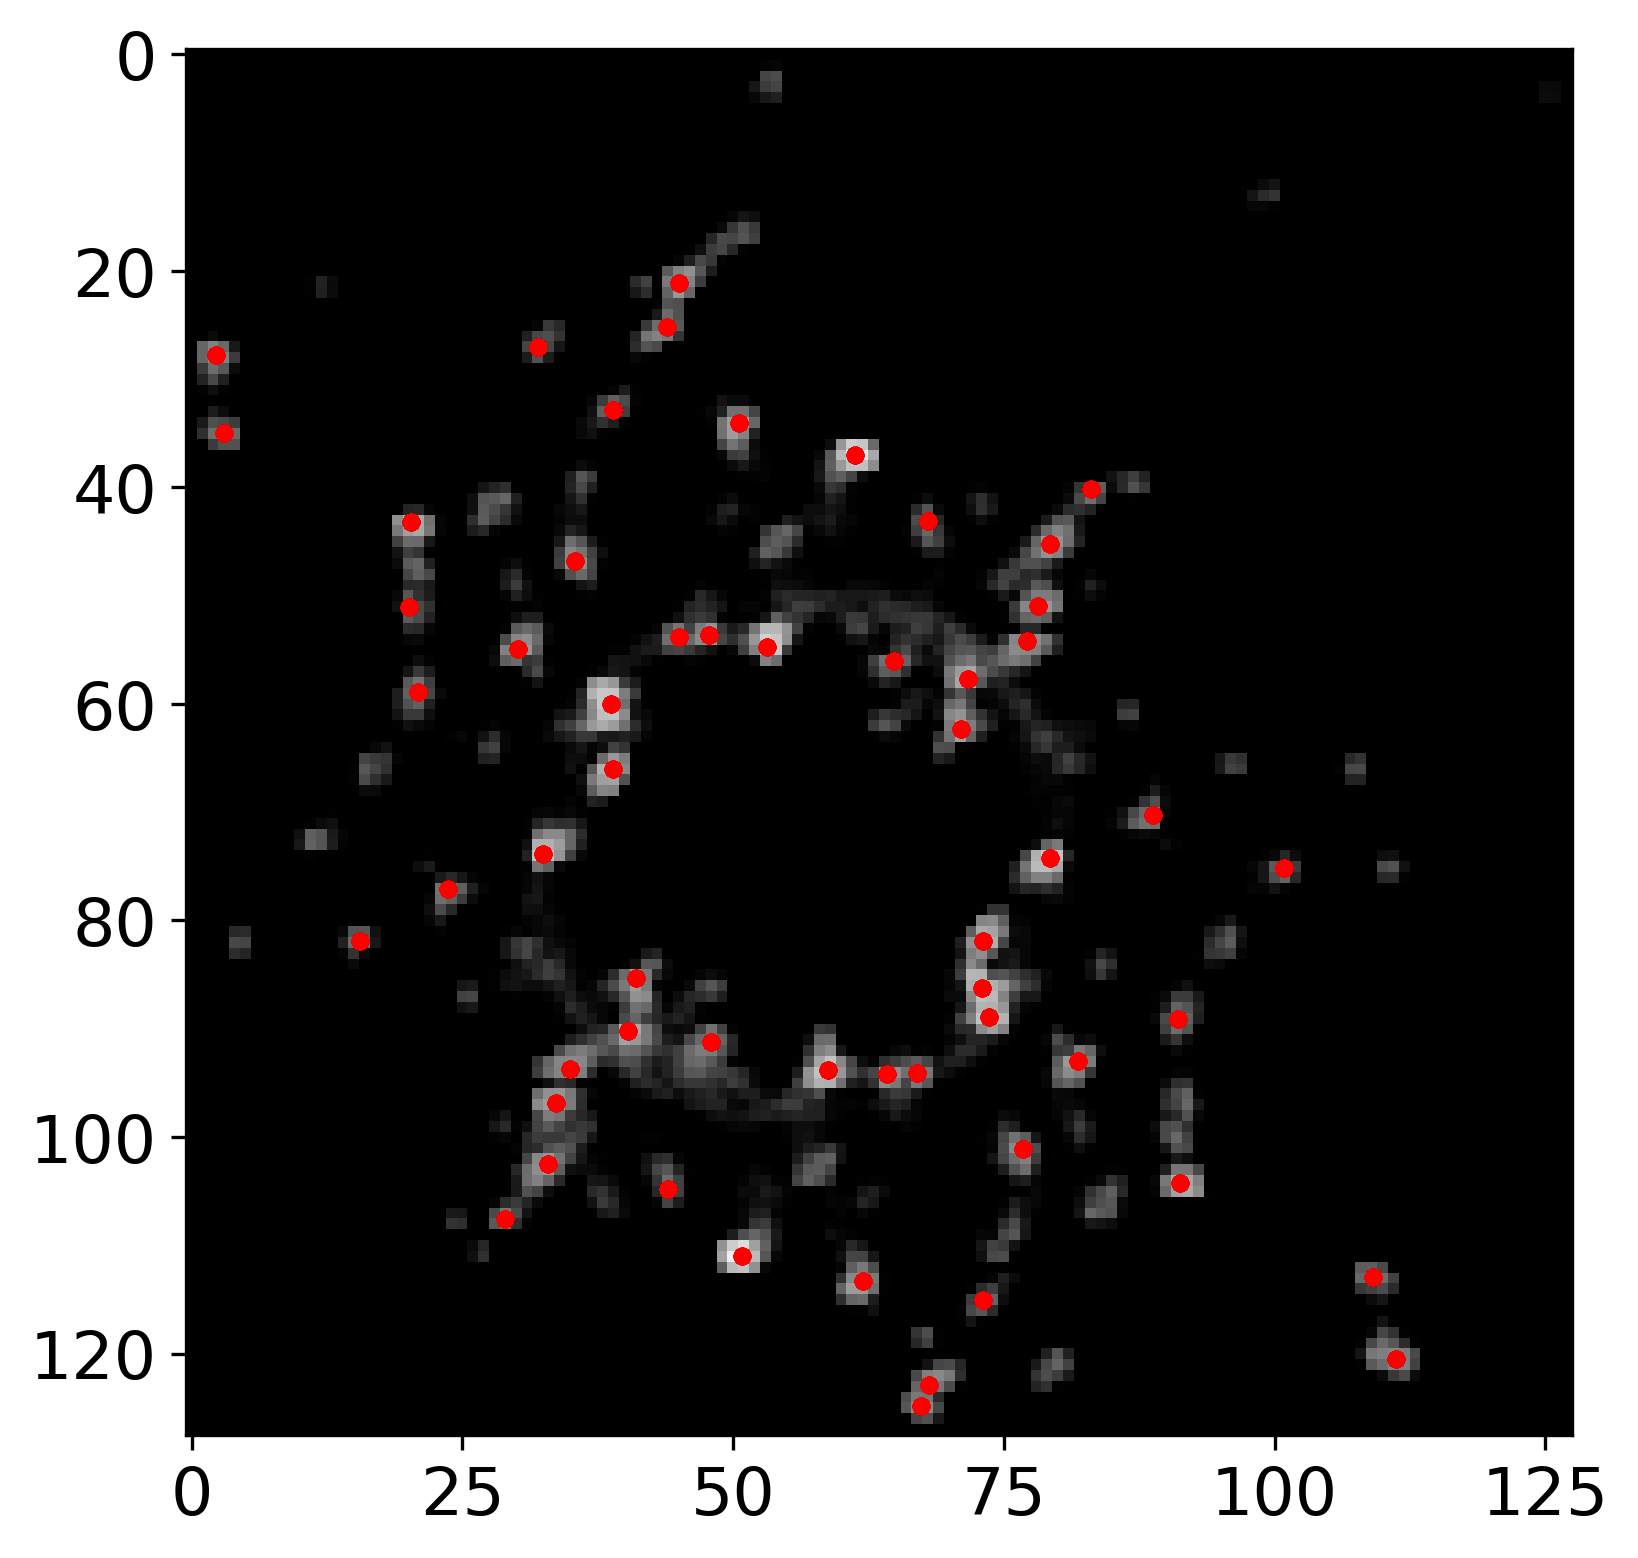

In [26]:
plt.imshow(np.log(bvm_raw+1), cmap='gray')
for i in range(len(gx)):
    plt.scatter(gy, gx, c='r', s=10)

# Obtain bragg disk intensity/probability list of DPs

In [27]:
braggpeaks_intensity = ObtainIntensityMatrix(datacube_symmetrize, braggpeaks_raw, 
                                             probe_kernel_FT, gx, gy)

# Select the number of segments using BIC rule 

[[1.0, 3.2035907546326015], [2.0, 5.964885030853012], [5.0990195135927845, 19.216846181690098], [3.1622776601683795, 12.683673322999164], [2.23606797749979, 9.555024873818542]] [1.         2.         5.09901951 3.16227766 2.23606798] [ 2.16584697  4.22887832 10.25193813  6.59608174  4.76186498]


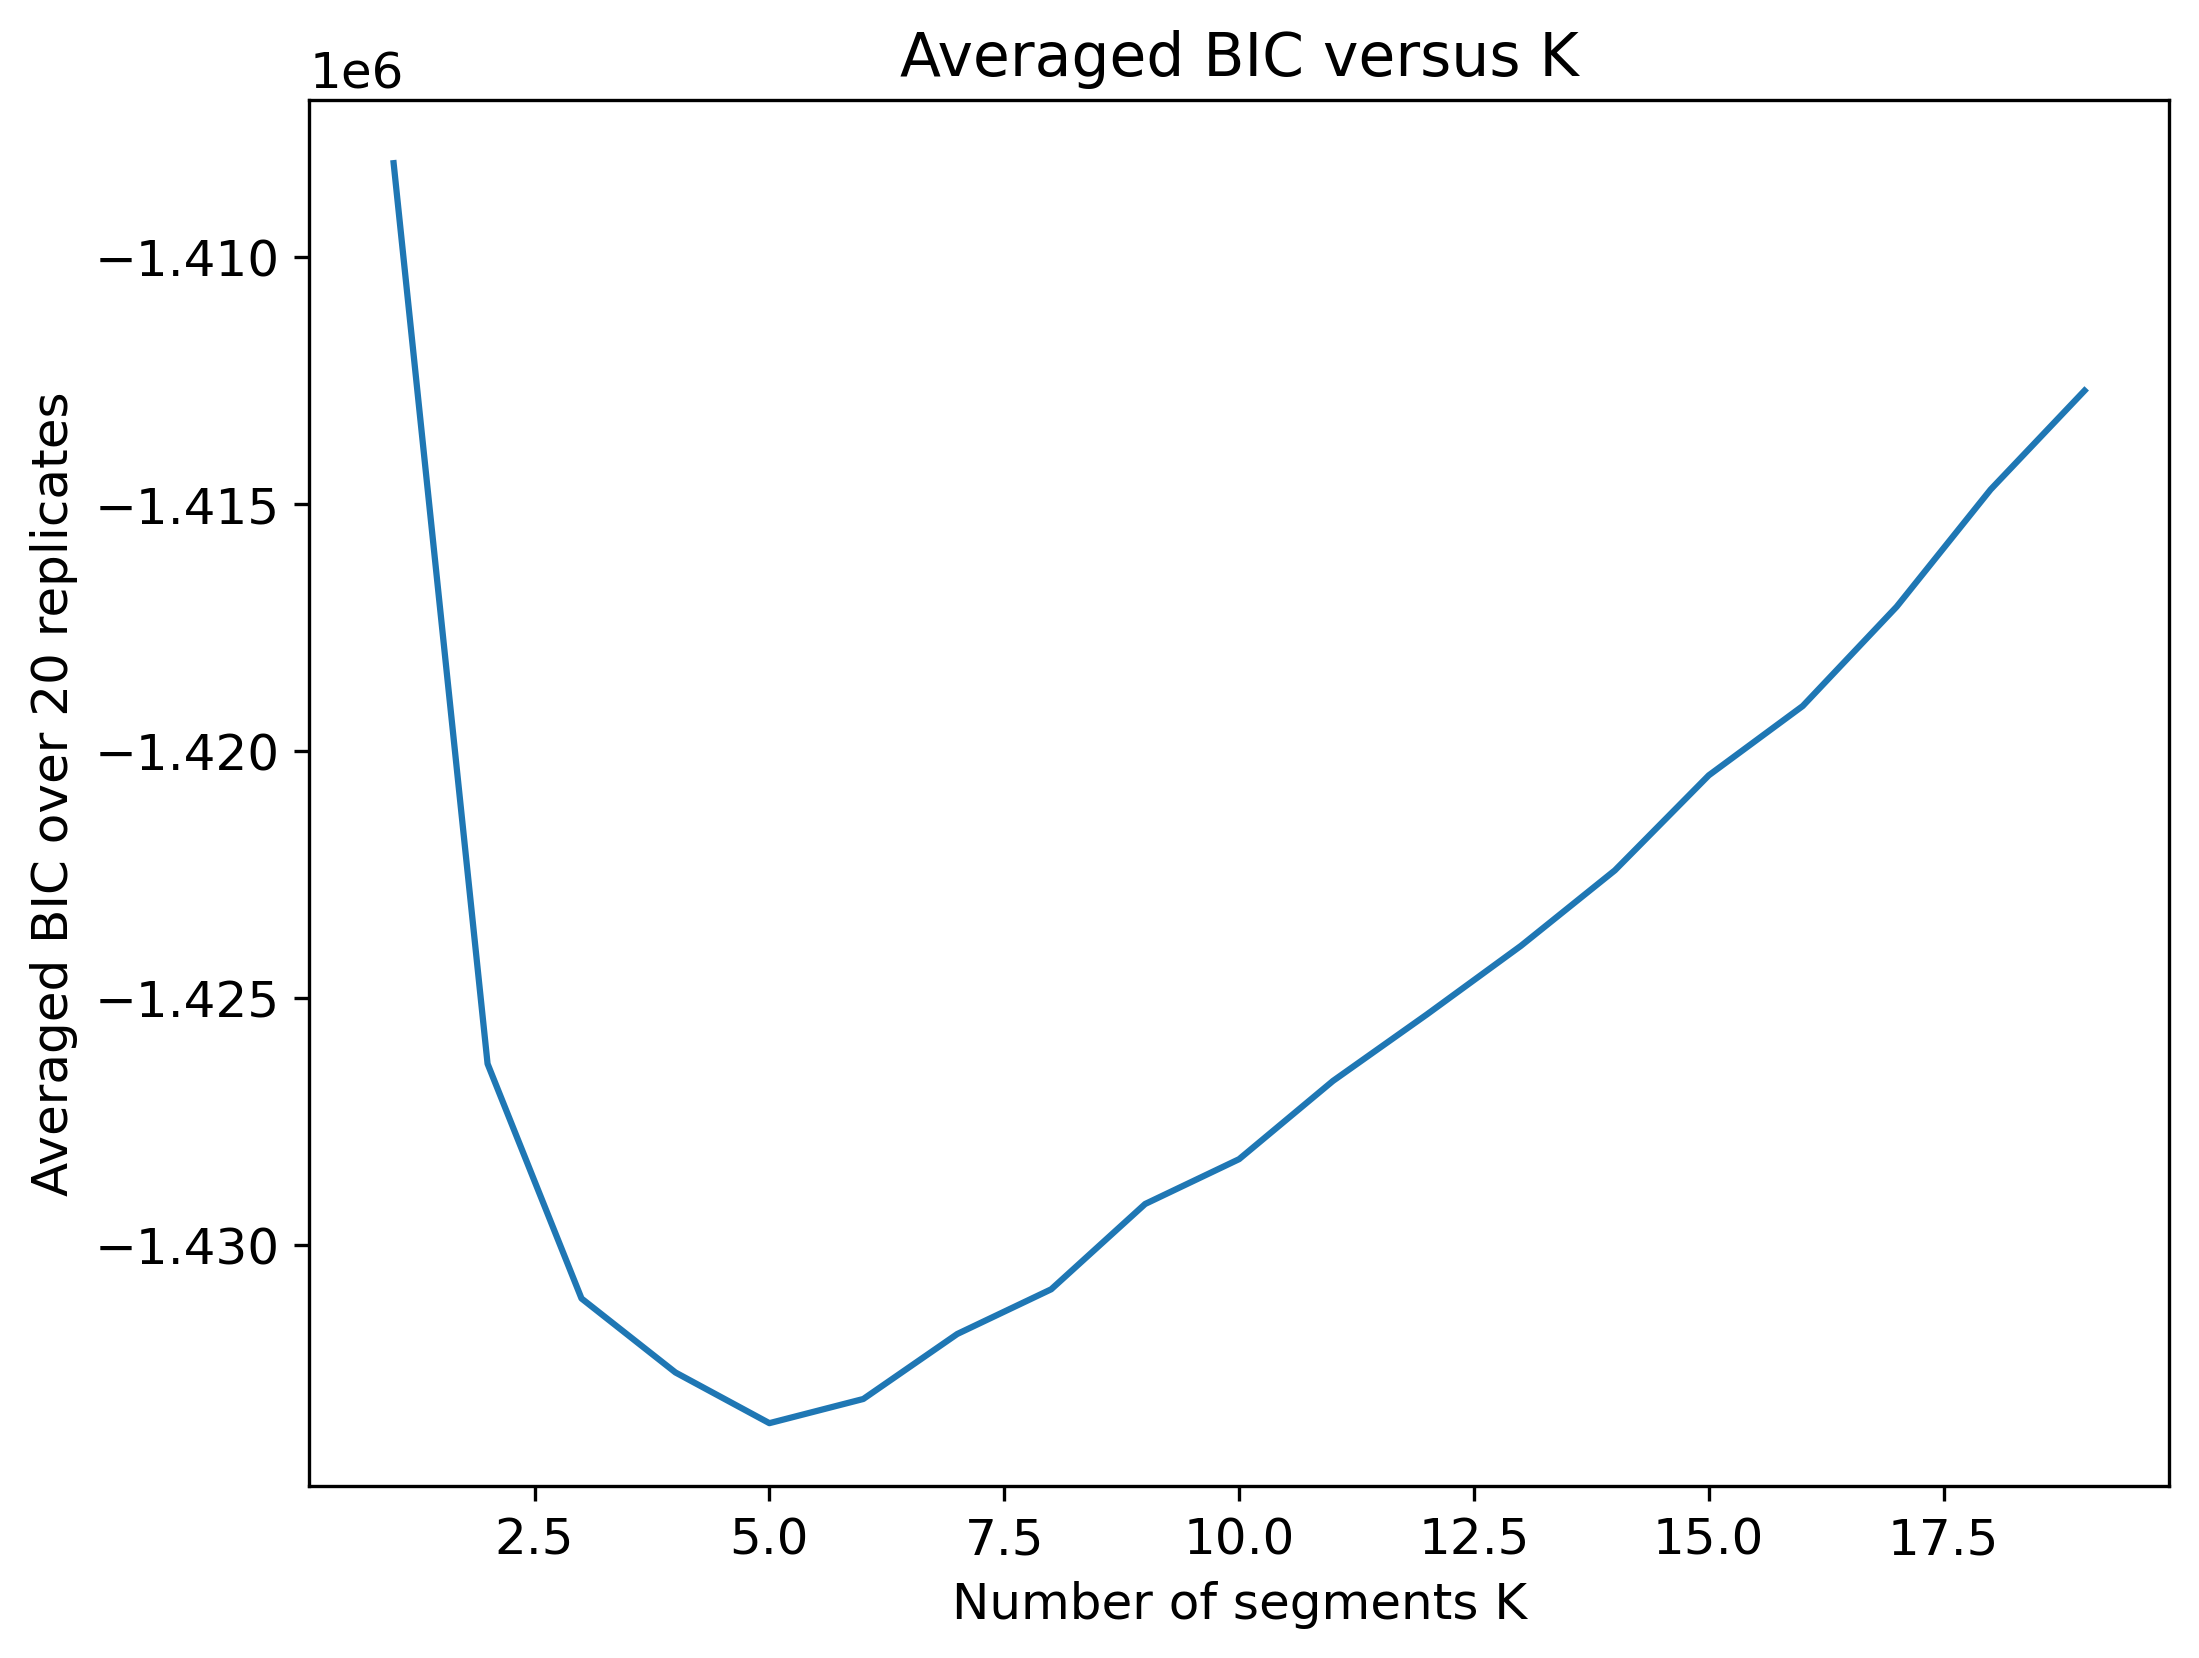

5 7.691841192085963e-06


In [28]:
start_time = time.time()
K_max = min(20, braggpeaks_intensity.shape[-1])
X_project, beta, pca = projection(braggpeaks_intensity, K_max, 
                                         datacube_symmetrize, particle_labels)

cov_matrix = np.cov(X_project.T)
eigvals, eigvectors = np.linalg.eig(cov_matrix)
coeff = np.min(eigvals) / np.max(eigvals)
alpha = 1e-8
if coeff < alpha:
    regu_para = alpha * np.max(eigvals)
else:
    regu_para = 0

np.random.seed(0)
seed_ls = np.random.choice(100, 20, replace=False)
n_componentsls = np.arange(1, 20)
b = [0] * n_componentsls.shape[0]
for seed in seed_ls:
    for i, n_component in enumerate(n_componentsls):
        gm = GaussianMixture(n_components=n_component, random_state=seed, 
                             reg_covar=regu_para, warm_start=True, covariance_type = 'full').fit(X_project)
        b[i] += gm.bic(X_project) / seed_ls.shape[0]

plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12
plt.plot(n_componentsls, np.array(b))
plt.title('Averaged BIC versus K')
plt.xlabel('Number of segments K')
plt.ylabel('Averaged BIC over %d replicates'%(20))
plt.show()
plt.close()

best_n = None
for i, n_component in enumerate(n_componentsls):
    if i == 0:
        continue
    if (b[i+1] > b[i]) and (b[i-1] > b[i]):
        best_n = n_component
        break
print(best_n, regu_para)

# GMM clustering

29


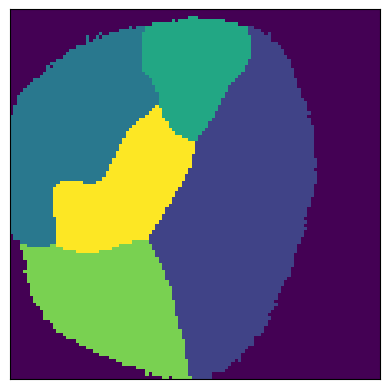

7.309543267885844


In [29]:
n_components = best_n
#n_components = 5
gm = GaussianMixture(n_components=n_components, random_state=0, 
                     reg_covar = regu_para, warm_start=True, covariance_type = 'full').fit(X_project)

label = np.zeros((particle_labels.shape))
label[np.where(particle_labels == 1)] = gm.predict(X_project)+1
#plt.scatter(30, 30, c='r')
prob = gm.predict_proba(X_project)
print(gm.n_iter_)
plt.style.use('default')
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.imshow(label)
#plt.colorbar()
plt.show()
plt.close()
print((time.time() - start_time)/60)

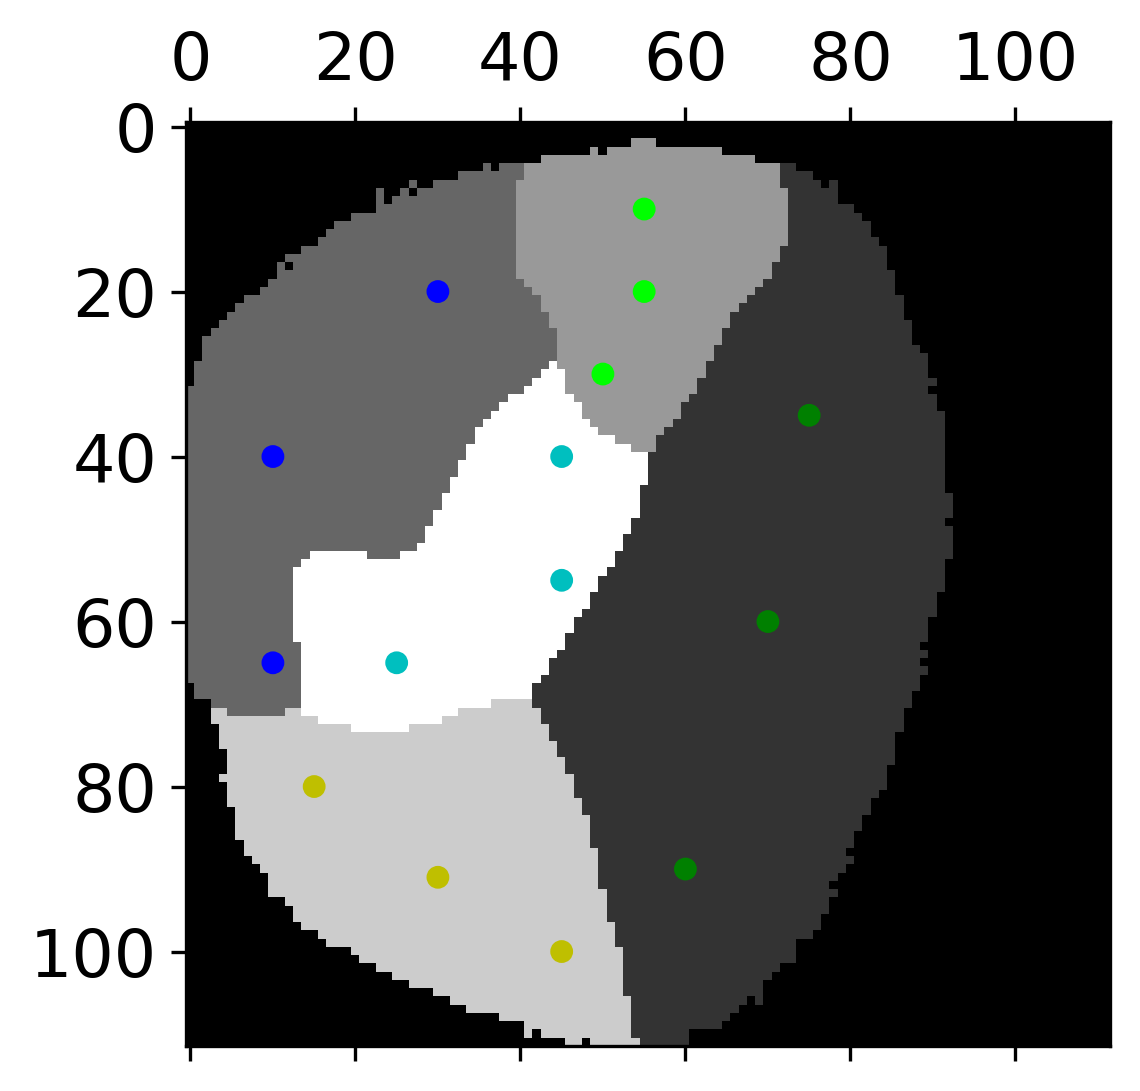

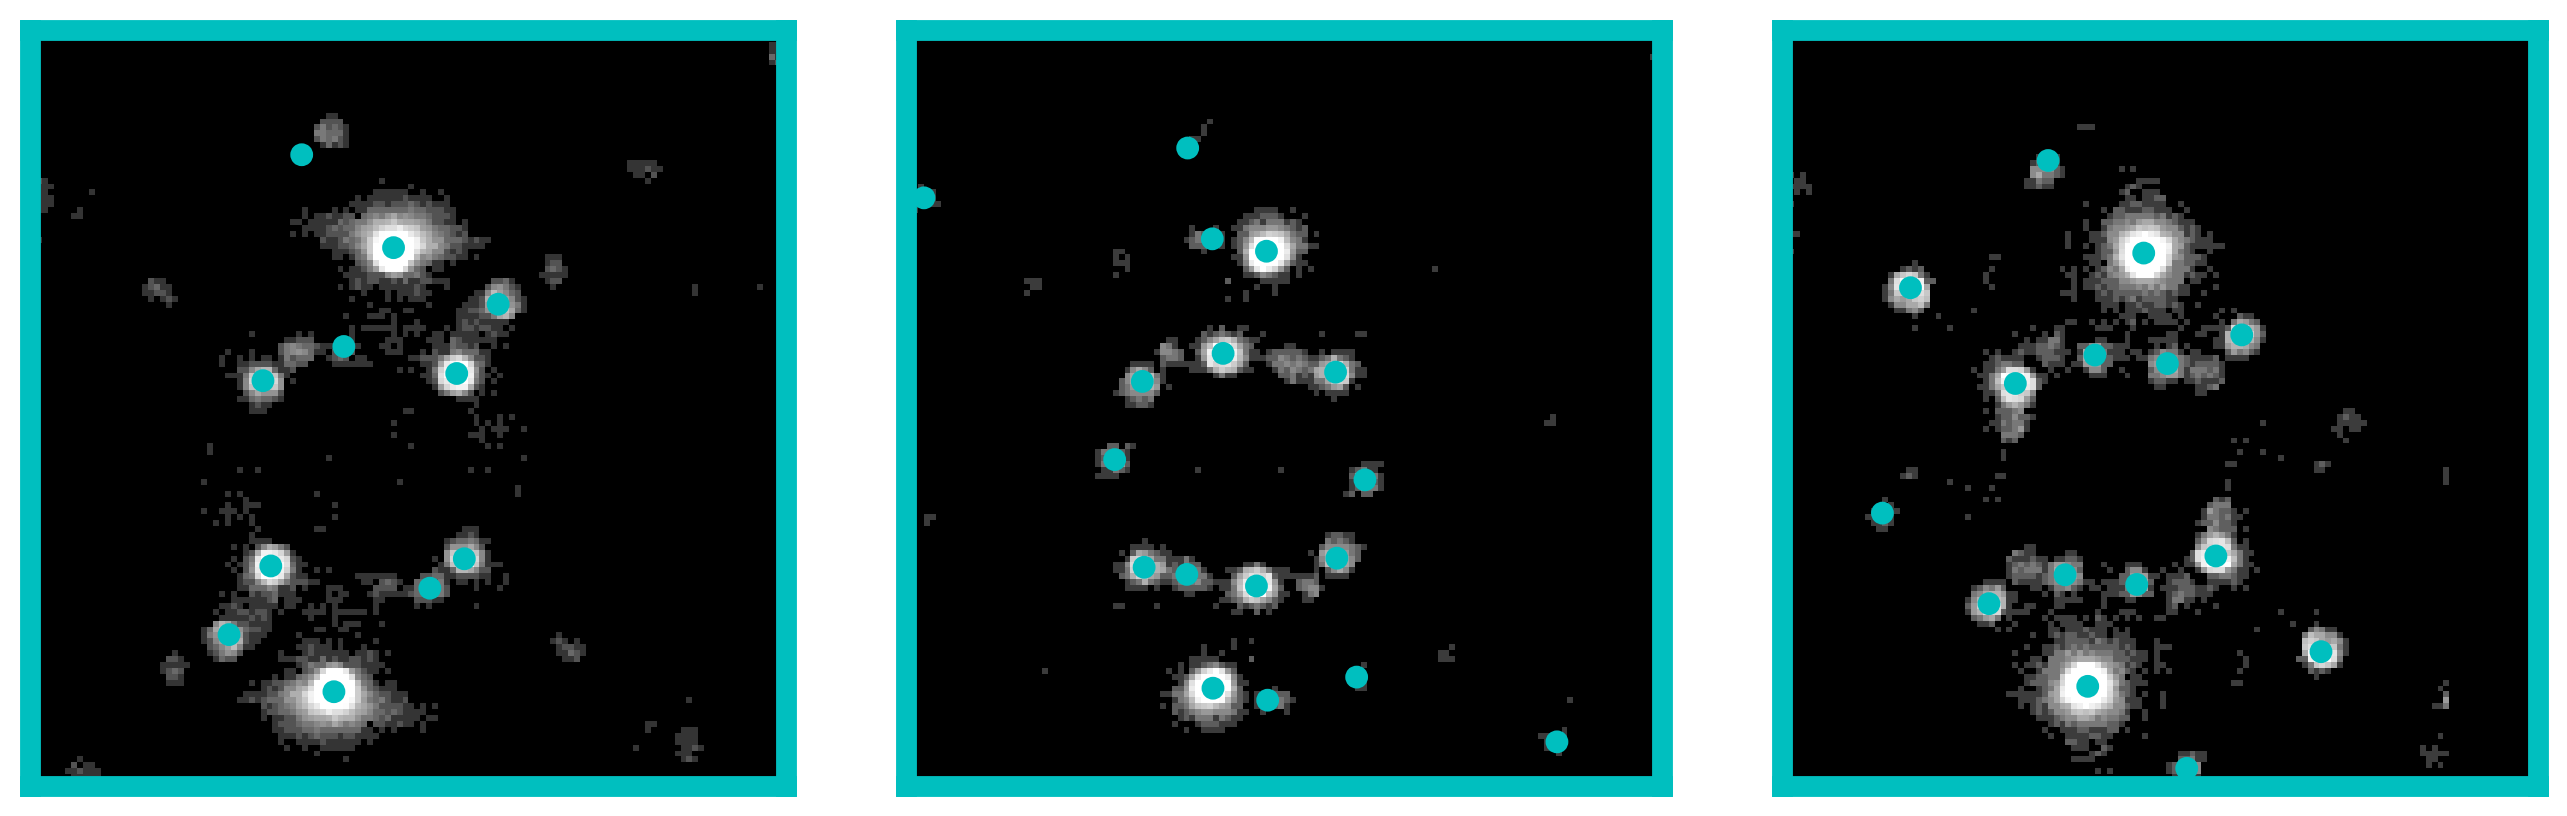

In [32]:
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'figure.dpi': 300})
rxs = 20,40,65,  40,55,65,  35,60,90,  10,20,30,  80,91,100 
rys = 30,10,10,  45,45,25,  75,70,60,  55,55,50,  15,30,45   
colors=['b','b','b', 'c','c','c',
        'g','g','g', 'lime','lime','lime', 'y','y','y']
py4DSTEM.visualize.show_points(label,x=rxs,y=rys,pointcolor=colors,figsize=(4,4),scale=20)

# cluster 1
k=1
dp1=datacube_symmetrize.data[rxs[0+k*3],rys[0+k*3],:,:]
dp2=datacube_symmetrize.data[rxs[1+k*3],rys[1+k*3],:,:]
dp3=datacube_symmetrize.data[rxs[2+k*3],rys[2+k*3],:,:]
py4DSTEM.visualize.show_image_grid(lambda i:[dp1,dp2,dp3][i],H=1,W=3,axsize=(3,3),
                                   scaling='log',
                                   scale = 20,
                                   get_bordercolor=lambda i:colors[i+k*3],
                                   get_x=lambda i:braggpeaks_raw.raw[rxs[i+k*3], rys[i+k*3]]._data['qx'],
                                   get_y=lambda i:braggpeaks_raw.raw[rxs[i+k*3], rys[i+k*3]]._data['qy'],
                                   get_pointcolors=lambda i:colors[i+k*3],
                                   )


# Probability plots

In [35]:
prob = gm.predict_proba(X_project)

cov_ls = []
for i in range(n_components):
    diff = X_project - gm.means_[i]
    cov = diff.T @ (prob[:, i][:, np.newaxis] * diff) / prob[:, i].sum()
    cov_ls.append(cov)
    
cluster1=5
cluster2=4
c_ls = ['b', 'orange', 'g', 'r', 'm', 'brown']
coord_ls, X_plot, prob, middle_idx, middle_points, middle_prob = plot_transit_prob(gm, cov_ls, c_ls, pca, braggpeaks_intensity, regu_para, 
                                         beta, label, cluster1, cluster2, 100)

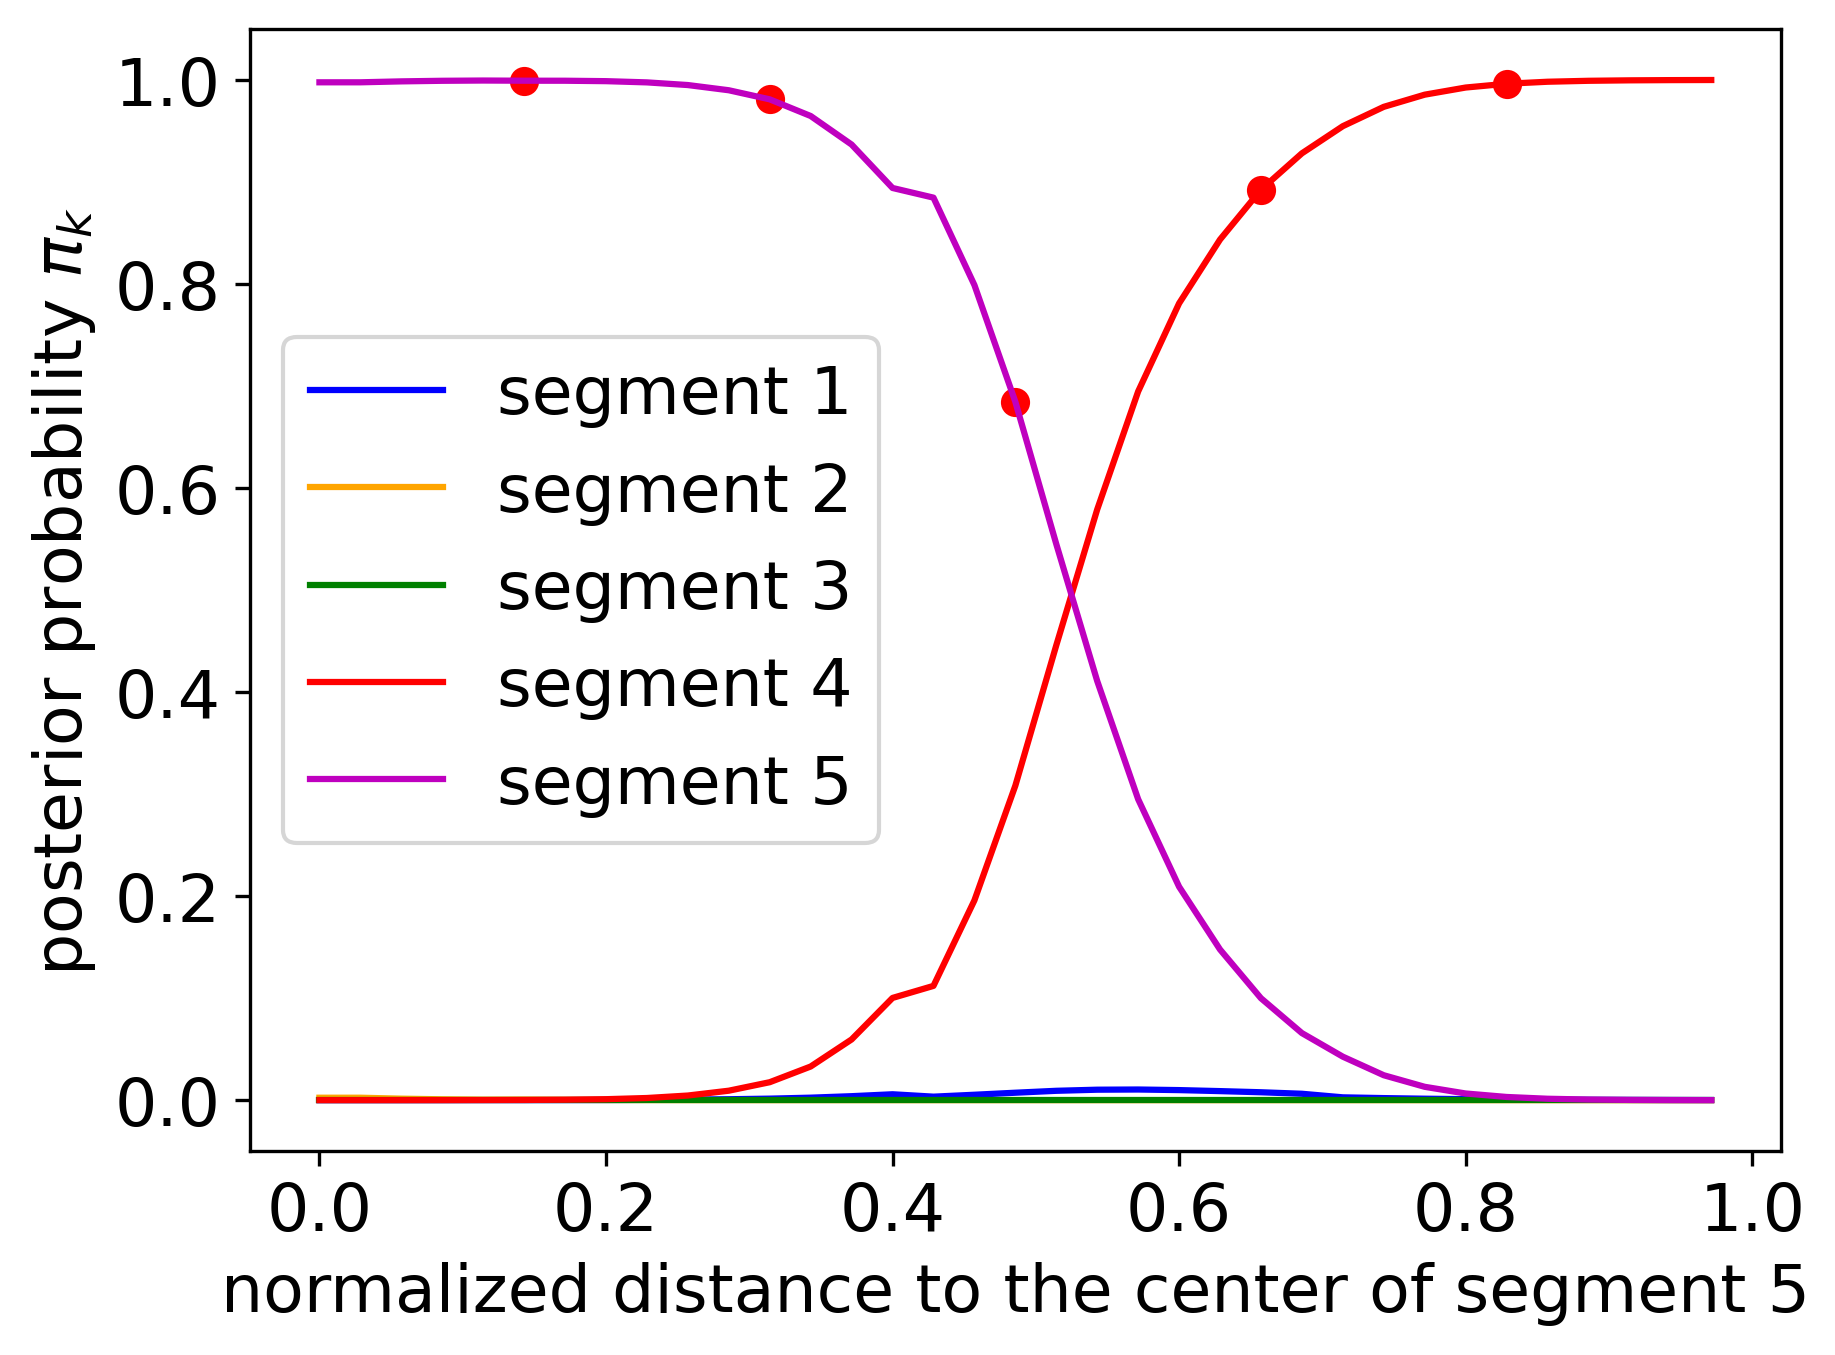

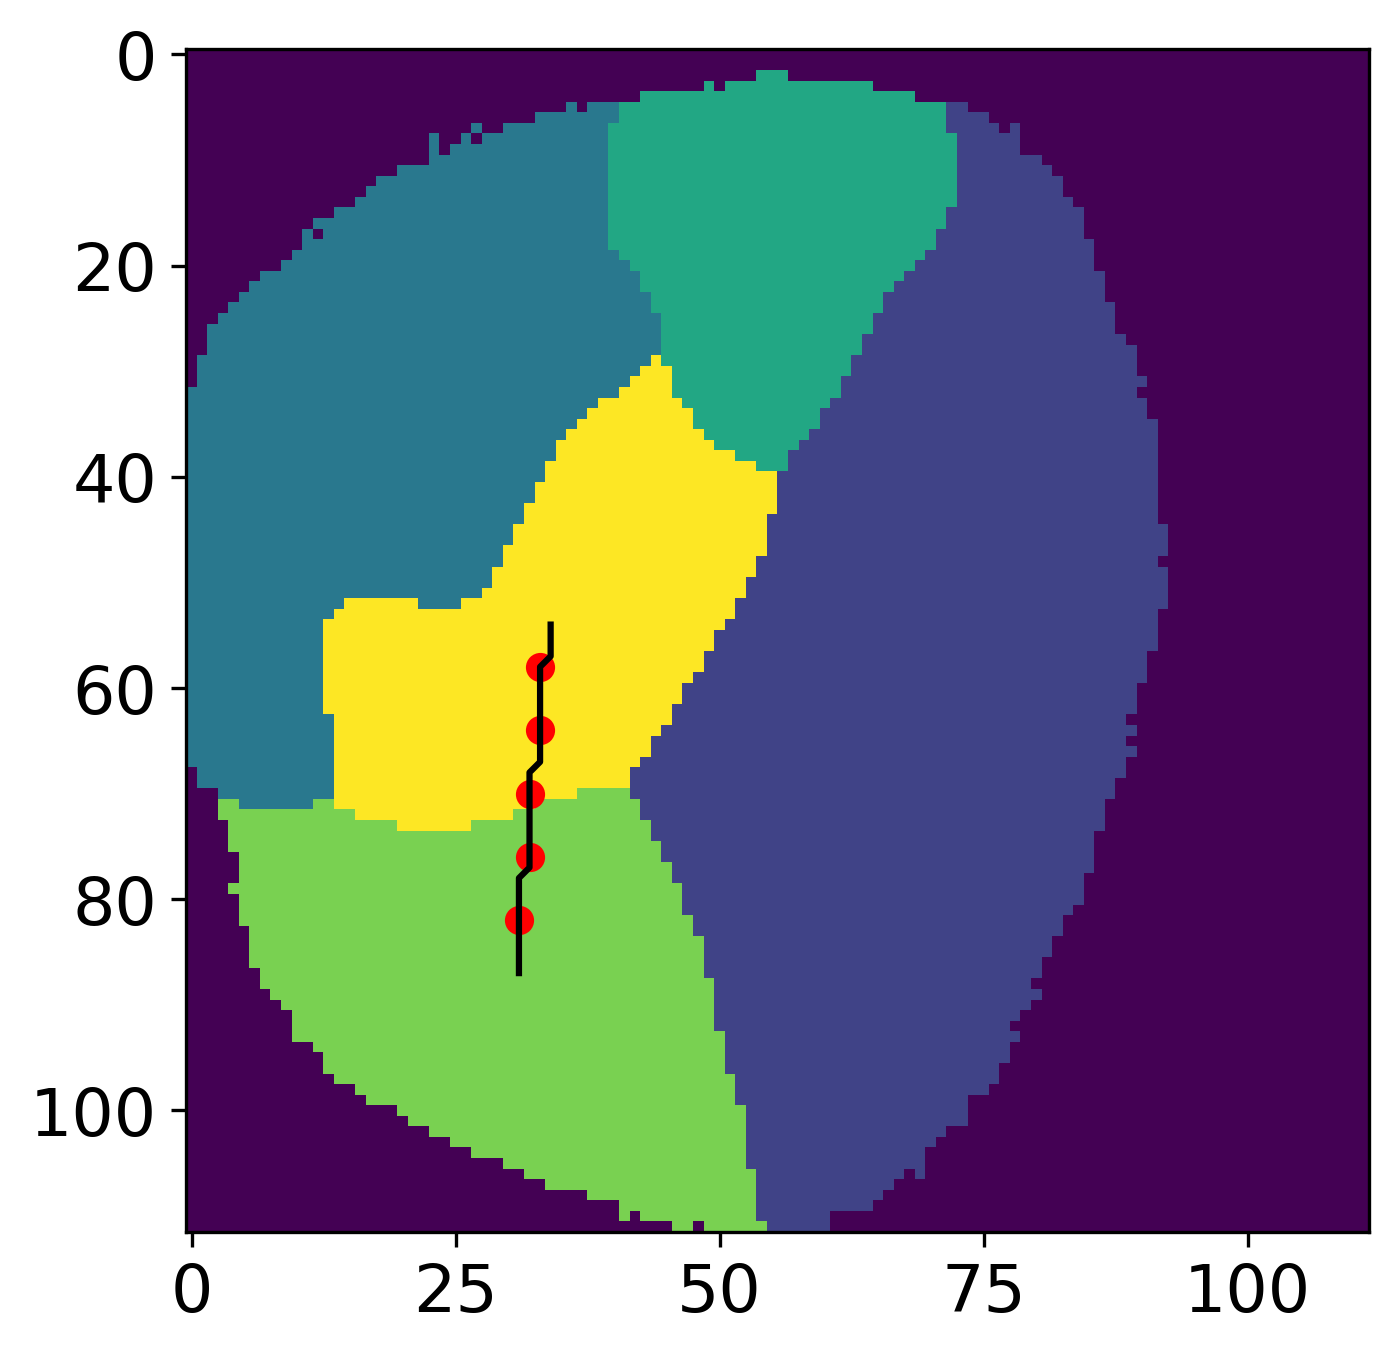

In [36]:
#draw the probability plot
n_samples = X_plot.shape[0]
for i in range(n_components):
    plt.plot(np.arange(n_samples)/n_samples, prob[:,i], c=c_ls[i], label='segment '+str(i+1))

plt.scatter(np.array(middle_idx)/n_samples, np.max(middle_prob, axis=1), c='red')
plt.xlabel('normalized distance to the center of segment %d' % (cluster2+1))
plt.ylabel('posterior probability $\pi_k$')
plt.legend()
plt.tight_layout()
#plt.savefig('./figs/probplot')
plt.show()
plt.close()

#draw the path in the segmentation plot
plt.imshow(label)
plt.plot(coord_ls[:, 1], coord_ls[:, 0], c='black')
plt.scatter(middle_points[:, 1], middle_points[:, 0], c='r')
plt.tight_layout()
#plt.savefig('./figs/segplot')
plt.show()
plt.close()

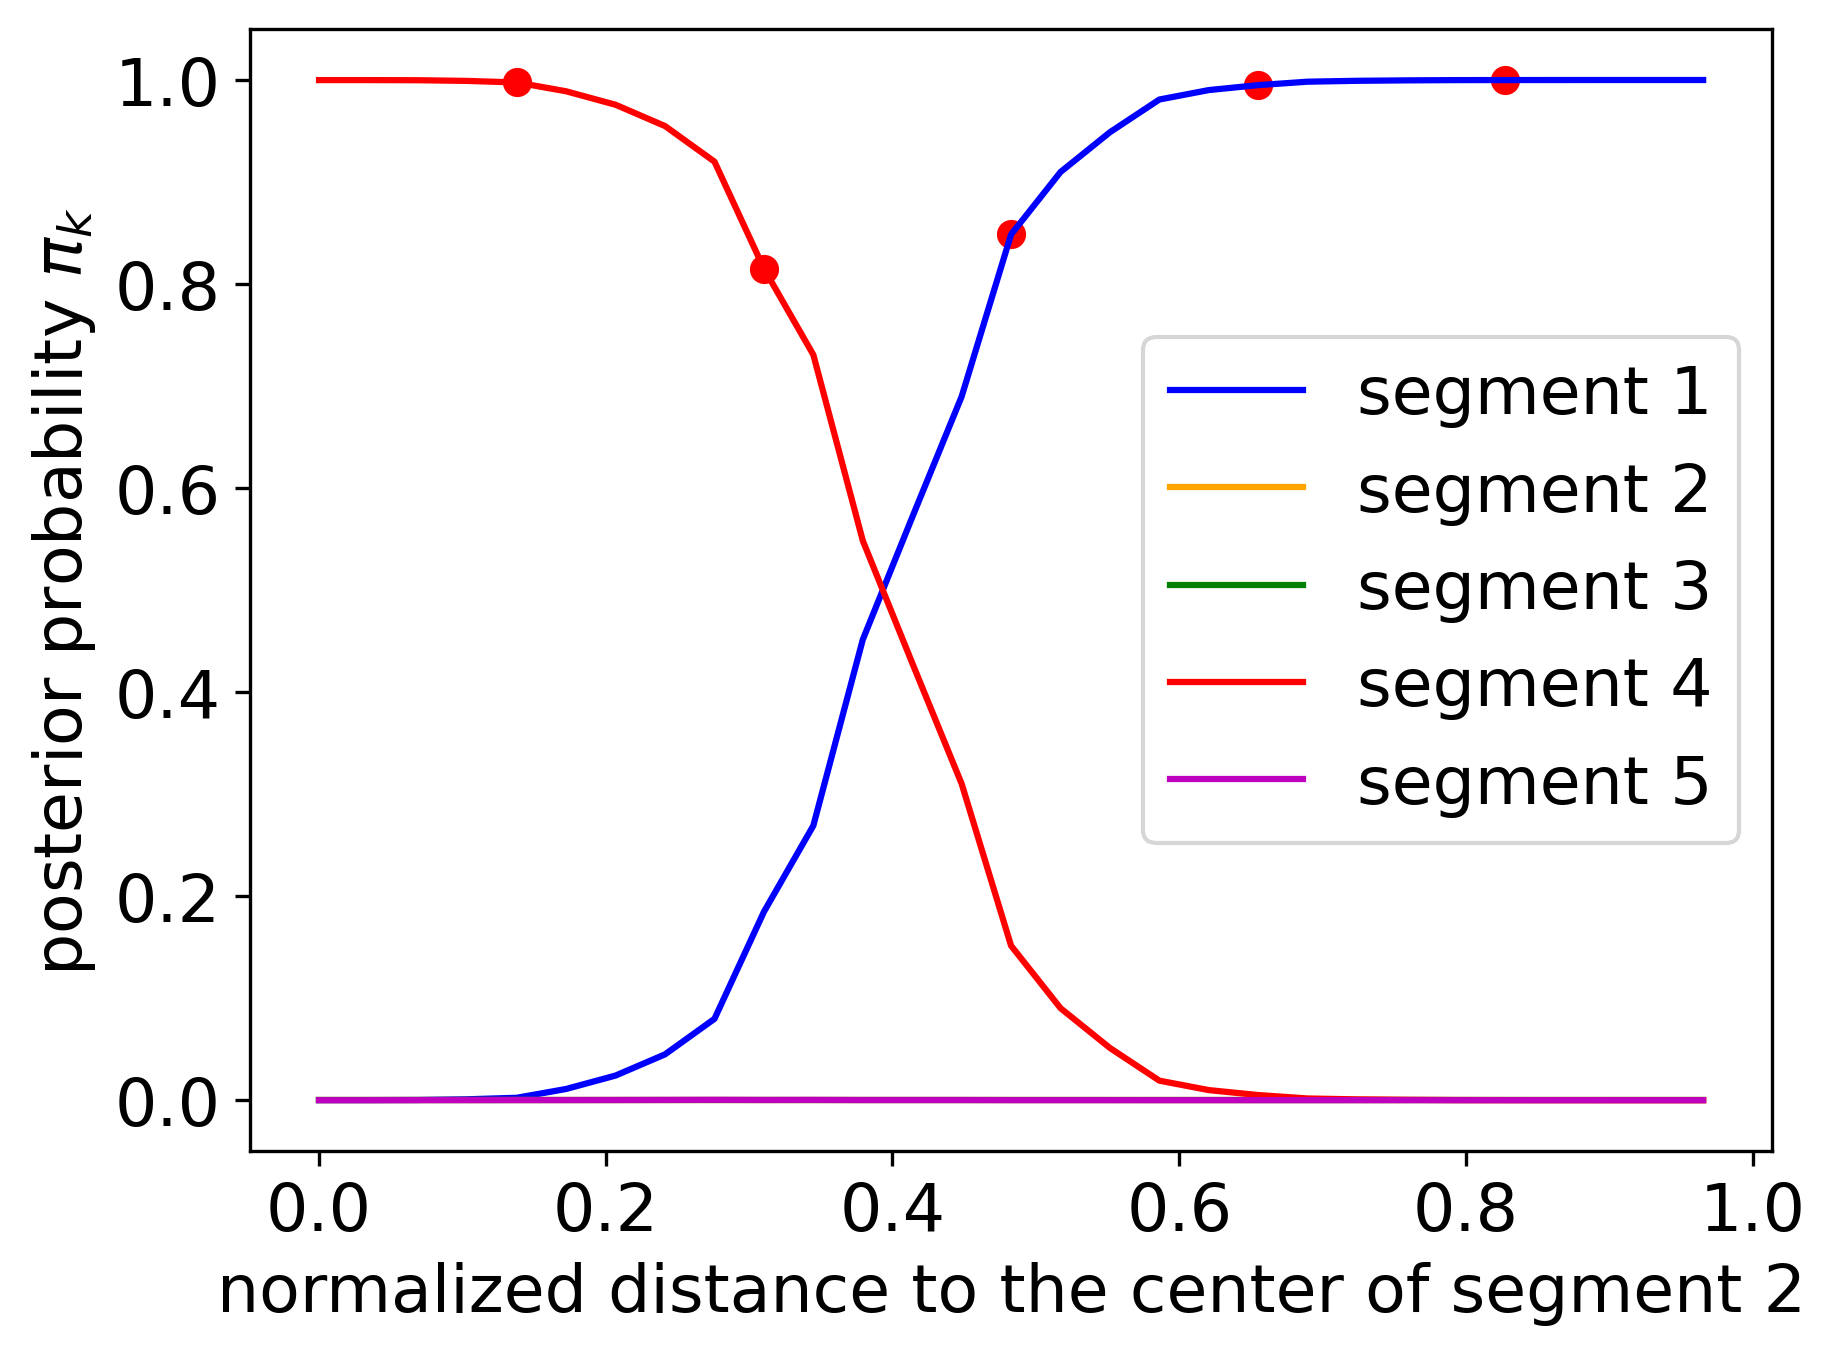

In [37]:
cluster1=4
cluster2=1
c_ls = ['b', 'orange', 'g', 'r', 'm', 'brown']
coord_ls, X_plot, prob, middle_idx, middle_points, middle_prob = plot_transit_prob(gm, cov_ls, c_ls, pca, braggpeaks_intensity, regu_para, 
                                         beta, label, cluster1, cluster2, 100)

#draw the probability plot
n_samples = X_plot.shape[0]
for i in range(n_components):
    plt.plot(np.arange(n_samples)/n_samples, prob[:,i], c=c_ls[i], label='segment '+str(i+1))

plt.scatter(np.array(middle_idx)/n_samples, np.max(middle_prob, axis=1), c='red')
plt.xlabel('normalized distance to the center of segment %d' % (cluster2+1))
plt.ylabel('posterior probability $\pi_k$')
plt.legend()
plt.tight_layout()
#plt.savefig('./figs/probplot')
plt.show()
plt.close()

# Transparency plot

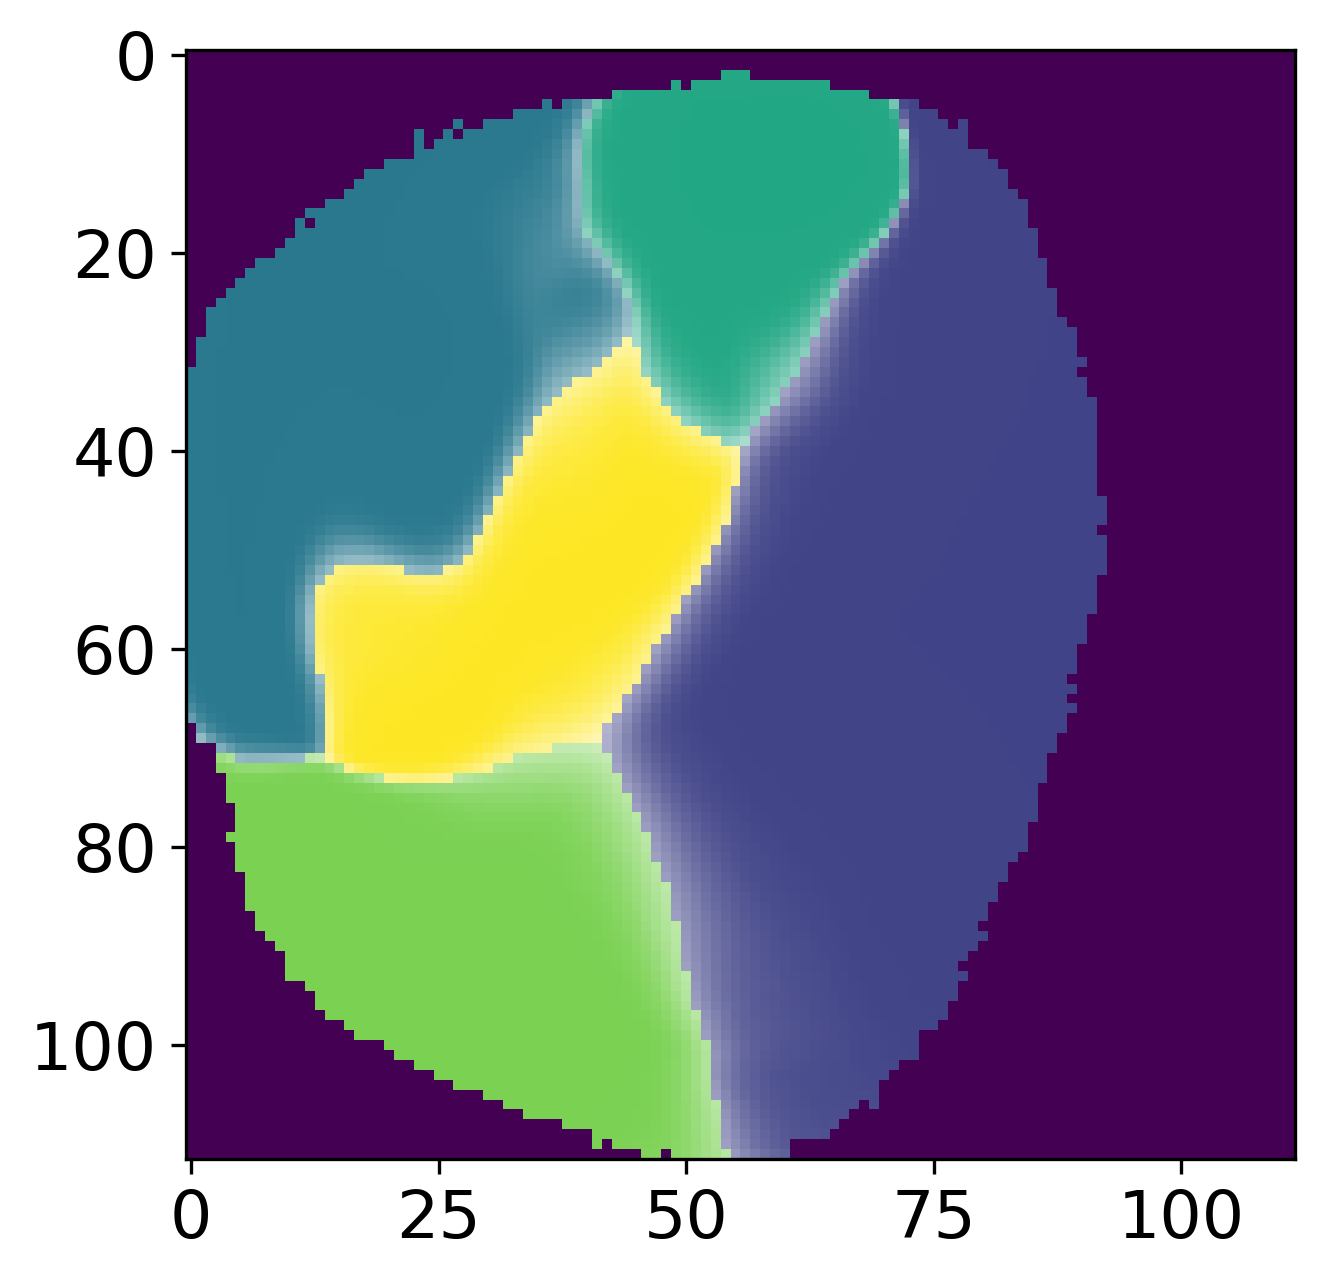

In [38]:
cluster_prob = np.ones(particle_labels.shape)
cluster_prob[np.where(label > 0)] = np.max(gm.predict_proba(X_project), axis = 1)
cluster_prob[np.where(label == 0)] = 1
plt.tight_layout()
plt.imshow(label, alpha = cluster_prob)
plt.show()
plt.close()